[Hugging Face Model Deployment](https://huggingface.co/spaces/namorafn7/term-deposit-subscription-model)

# i. Introduction

================================================= <br>
**Data-Driven Term Deposit Subscription Modeling for Marketing Campaigns**

Name : Fernando Namora <br>
Date Creation : February 4, 2026

This notebook is built to data modelling for predict the client will subscribe a term deposit based on bank marketing campaigns historical data. <br>
================================================= <br>


## Dataset Information:

Source of Dataset: [UC-Irvine](https://archive.ics.uci.edu/dataset/222/bank+marketing)

| Column | Description |
| --- | --- |
| `age` | age of the client |
| `job` | type of job of the client |
| `marital` | marital status |
| `education` | education level |
| `default` | the client has credit in default ? |
| `balance` | average yearly balance |
| `housing` | the client has housing loan ? |
| `loan` | the client has personal loan ? |
| `contact` | contact communication type |
| `day` | last contact day of the month |
| `month` | last contact month of the year |
| `duration` | the duration in second of this call data |
| `campaign` | number of contacts performed during this campaign and for this client |
| `pdays` | number of days that passed by after the client was last contacted from a previous campaign (`-1` means the client was not previously contacted) |
| `previous` | number of contacts performed before this campaign and for this client |
| `poutcome` | outcome of the previous marketing campaign |
| `y` | has the client subscribed a term deposit ? |

<br>

> **Special Note:** <br>
> From the dataset source information, the column `duration` highly affects the output target, since in realistic scenario when the call is performed and have a duration of the call, it is obviously known what the result (`y`) at the end of the call. So, this column should be discarded if the intention to be applicable for realistic scenario

---

## Problem Statement:

Deposits are an important source of stable funding for banks and play a critical role to ensure stability of the banking system. One of the financial instruments offered by banks to support capital growth and funding stability is **the term deposit**. A term deposit is a type of financial account where customers deposit money for a fixed period of time and receive interest based on the agreed terms. In banking, term deposits are considered type of savings, which can be short-term or long-term depending on bank regulations and product offerings.

The dataset comes from a Portuguese banking institution namely The Bank, that conducted **direct marketing campaigns through phone calls**. The objective of these campaigns was to encourage customers to **subscribe to term deposit** products. However, not all contacted customers were ended up interested and subscribed, which resulted inefficient marketing resources.

The marketing team requests a Data Scientist to build a **predictive model to identify customers who are more likely to subscribe to a term deposit**. By predicting customer subscription behavior, the Bank can target specific potential customers more effectively and improve the efficiency for **future marketing campaigns**.

> References:
> - [Term-deposit](https://www.investopedia.com/terms/t/termdeposit.asp)
> - [How-term-deposits-work](https://www.amp.com.au/resources/insights-hub/what-is-a-term-deposit)
> - [Deposits-are-an-important-source-of-stable-fundings-for-banks](https://www.accc.gov.au/system/files/National%20Australia%20Bank%20Limited_0.pdf)

**Target users** on this project: The marketing teams from the Bank

---

## Objective:

This project is to create **Machine Learning classification model** to predict whether the client that will be reached out by phone calls will subscribe to a term deposit products, based on historical dataset. The model is chosen from several algorithms: **KNN**, **SVM**, **Decision Tree**, **Random Forest**, and **AdaBoost**. From all of these models, the best model chosen by evaluated using **Confusion Matrix** and **Precision** score metric. The best model is tuned with **Hyperparameter Tuning** and re-evaluated the performance. The final model is re-evaluated that have **good predictive score**, **low overfitting**, and **stable** to predict potential client that will subscribe to help **future marketing campaigns**. Exploratory Data Analysis (EDA) is also conducted to answer business-related questions and gain insights from historical data before proceeding to feature engineering and modeling.

# ii. Import Libraries

In [1]:
# import libraries used for this project

# basic EDA libraries:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# machine learning preprocessing libraries:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer # to impute missing values
from sklearn.compose import ColumnTransformer # for preprocessing split
from feature_engine.outliers import Winsorizer # for capping in outliers handling
import phik # for feature selection process - note: may need to pip install first if needed

# for pipeline libraries
from sklearn.pipeline import make_pipeline

# machine learning algorithm libraries:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier # ensemble learning algorithms

# for model evaluation
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_score, make_scorer

# for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# for model saving
import pickle

# suppress warnings from pandas
import warnings
warnings.filterwarnings("ignore")

# iii. Data Loading

In [2]:
dataset = pd.read_csv('bank-full.csv', sep = ';') # use original dataset separator

# inspect the data
dataset

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


Above is the preview of the dataset from `bank-full.csv`, there are 45211 rows and 17 columns. We will assign to a new variable `df` the copy of `dataset` for further exploration and model creation:

In [3]:
# assign to new variable
df = dataset.copy()

# see the shape of data
print(f'The shape of df (dataset) is {df.shape}\n') # new line to separate

# inspect summary of data from .info method
df.info()

The shape of df (dataset) is (45211, 17)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


From above output, we have summary information that from all 45211 rows and 17 columns, there are no missing values. Based on the dataset summary and information, the features can be grouped into categorical and numerical variables. All columns follow each behavior data type, except for `day`, since it represents the day from the date. The column `day` is **categorical ordinal** (since there is an order) instead of numerical feature, hence we will change to the type `object`.

Notice that from earlier **Dataset Information** we will not use column `duration` for realistic model. Because this column is known together with the target `y`, means we cannot know the value for **unseen data**. This is data leakage condition, hence we will **drop this column `duration`**.

Another one, we may also notice by the definition of following columns as well:
- `campaign`: number of contacts performed **during this campaign** and for this client
- `pdays` : number of days that passed by after the client was last contacted from **previous campaign** (-1 means client was not previously contacted)
- `previous` : number of contacts performed **before this campaign** and for this client
- `poutcome` : outcome of the **previous marketing campaign**

Note that the term deposit is not a **life-time** products, it can be based on bank regulations whether to automatic renewal the products or not. Hence, it is normal for marketing team to **re-approach** customer that **previously subscribed**, which means success on previous campaign. Therefore, `previous`, `pdays`, and `poutcome` are not data leakage columns, we will keep it for now.
> Reference of term deposit rollover, maturity, and renewal: [link](https://www.infochoice.com.au/term-deposits/what-you-need-to-know-about-term-deposit-rollovers)

Also, note that from the values of column `campaign` some have value more than 1. This means that the term deposit campaign also is not **short period**, means it is normal to contact same customer a few times. So, this is also not data leakage column, because it is based on past information **from the perspective of the campaign at the time of data collection**, not future knowledge. Therefore, we will keep this column for now.

In [4]:
# change data type day
df['day'] = df['day'].astype(object)

# drop column `duration`
df = df.drop('duration', axis = 1) # column-wise

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no


If we check duplicate data:

In [5]:
print(f'There are {df.duplicated().sum()} data duplicate')

# check the data
df[df.duplicated(keep=False)] # use keep=False to see first data (as basis)

There are 16 data duplicate


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
2807,44,services,single,secondary,no,0,yes,no,unknown,14,may,1,-1,0,unknown,no
2871,44,services,single,secondary,no,0,yes,no,unknown,14,may,1,-1,0,unknown,no
4878,34,management,single,tertiary,no,0,yes,no,unknown,21,may,1,-1,0,unknown,no
4910,34,management,single,tertiary,no,0,yes,no,unknown,21,may,1,-1,0,unknown,no
12754,25,blue-collar,married,primary,no,0,no,no,cellular,7,jul,1,-1,0,unknown,no
12939,25,blue-collar,married,primary,no,0,no,no,cellular,7,jul,1,-1,0,unknown,no
13576,47,services,married,secondary,no,0,yes,no,cellular,9,jul,1,-1,0,unknown,no
13662,47,services,married,secondary,no,0,yes,no,cellular,9,jul,1,-1,0,unknown,no
15760,35,management,married,tertiary,no,0,yes,no,cellular,21,jul,3,-1,0,unknown,no
15836,35,management,married,tertiary,no,0,yes,no,cellular,21,jul,3,-1,0,unknown,no


Some observations in the dataset appear as exact duplicates from all features value. These duplicated rows do not provide additional information and may add redundancy during model training. Hence, we will drop these duplicated records, and keeping single representative (first one of duplicated records):
> When drop duplicate, we will not input argument `keep = False` to retained first one of duplicates

In [6]:
# drop duplicate, not keep = False so the first one keep retained as representative
df = df.drop_duplicates().reset_index(drop=True) # in order the index reset to 0, 1, ... ; drop the index from column

If we check again the summary of the dataset and the duplicates number of data:

In [7]:
# number of duplicates
print(f'There are {df.duplicated().sum()} data duplicate')

# see the shape of data
print(f'The shape of df (dataset) is {df.shape}\n') # new line to separate

# inspect summary of data from .info method
df.info()

There are 0 data duplicate
The shape of df (dataset) is (45195, 16)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45195 entries, 0 to 45194
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45195 non-null  int64 
 1   job        45195 non-null  object
 2   marital    45195 non-null  object
 3   education  45195 non-null  object
 4   default    45195 non-null  object
 5   balance    45195 non-null  int64 
 6   housing    45195 non-null  object
 7   loan       45195 non-null  object
 8   contact    45195 non-null  object
 9   day        45195 non-null  object
 10  month      45195 non-null  object
 11  campaign   45195 non-null  int64 
 12  pdays      45195 non-null  int64 
 13  previous   45195 non-null  int64 
 14  poutcome   45195 non-null  object
 15  y          45195 non-null  object
dtypes: int64(5), object(11)
memory usage: 5.5+ MB


After above process, now there are no duplicates, we have 45195 rows and 16 columns, also no missing values on the dataset.

Next, we can see basic range of numerical columns of the dataset with describe method:

In [8]:
df.describe()

,age,balance,campaign,pdays,previous
count,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000
mean,40.937604,1362.754331,2.763978,40.212413,0.580529
std,10.619108,3045.196838,3.098304,100.143468,2.303823
min,18.000000,-8019.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,1.000000,-1.000000,0.000000
50%,39.000000,449.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,63.000000,871.000000,275.000000


It is noticeable what need to be cautious is **negative value** of column `balance`. From dataset information, this column should be depict **average yearly balance**. If we see further from the data where this column negative:

In [9]:
df[df['balance'] < 0]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
25,44,admin.,married,secondary,no,-372,yes,no,unknown,5,may,1,-1,0,unknown,no
28,46,management,single,secondary,no,-246,yes,no,unknown,5,may,2,-1,0,unknown,no
36,25,blue-collar,married,secondary,no,-7,yes,no,unknown,5,may,1,-1,0,unknown,no
37,53,technician,married,secondary,no,-3,no,no,unknown,5,may,1,-1,0,unknown,no
45,36,admin.,single,primary,no,-171,yes,no,unknown,5,may,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44610,31,services,single,secondary,no,-205,no,no,cellular,1,sep,1,579,1,failure,yes
44613,28,blue-collar,single,secondary,no,-46,yes,no,cellular,1,sep,1,92,14,success,yes
44820,33,blue-collar,married,primary,no,-195,no,no,unknown,20,sep,1,-1,0,unknown,no
44892,48,management,divorced,tertiary,no,-130,yes,no,cellular,29,sep,2,61,9,failure,no


We may conclude that these customers are in a state of **debt** with the Bank, at the point when this historical dataset fetched. However, these customers are not generally justified to be bad customers, because there may be a good debt customers especially this is normal in bank condition. Moreover, if we see closely on the preview of the dataset earlier, some of customers with negative balance ended up subscribed to a term deposit. There is no way the Bank will approve the term deposit application for a bad customer, so these customers are important for the prediction in this project. Therefore, we conclude that we will **retain** these data as it is.
> References: [bad-debt-vs-good-debt](https://www.consolidatedcreditcanada.ca/financial-news/bad-debt-vs-good-whats-the-difference/)

In [10]:
df.describe()

,age,balance,campaign,pdays,previous
count,45195.000000,45195.000000,45195.000000,45195.000000,45195.000000
mean,40.937604,1362.754331,2.763978,40.212413,0.580529
std,10.619108,3045.196838,3.098304,100.143468,2.303823
min,18.000000,-8019.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,1.000000,-1.000000,0.000000
50%,39.000000,449.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,63.000000,871.000000,275.000000


By above output, **except** `balance` there are no problematic numerical columns such as negative value, unreasonable high value, etc. For `pdays` it is normal to have value -1, because from dataset information when `pdays = -1` means the client is not contacted earlier on this historical dataset. Hence, we can move further on the next process that is **Exploratory Data Analysis**.

# iv. Exploratory Data Analysis

Main question for **Exploratory Data Analysis (EDA)** of this project, arise from the questions:

1. What is the percentage of subscribed vs. non-subscribed customers in this historical dataset?
2. How is the distribution of subscribed vs non-subscribed customers for each marital status type?
3. When is the date of the year that have the highest frequencies of clients contacted? Are there specific months of the year when past clients are contacted more frequently?
4. Does past campaign informations, which is `pdays`, `previous`, and `poutcome` features have strong association to predict variable whether the client will subscribe term deposit?
5. How is the distribution of numerical features (`age`, `balance`, `campaign`, `pdays`, and `previous`)? Does all have normal distribution? 
6. From the answer of the question no.4, are there numerical features that need logarithmic transformation?

## 1. What is the percentage of subscribed vs. non-subscribed customers ?

If we look at the frequencies of subscribed and non-subscribed customers in this historical dataset, also see the percentage:

In [11]:
frequencies = df['y'].value_counts()
table_print = pd.DataFrame(frequencies)

# calculate the percentage
# times 100 first
table_print['percentage'] = (
    table_print['count'] * 100)/(table_print['count'].sum()
)

# then round 2 decimal 
# and change to string and show % at the end
table_print['percentage'] = table_print['percentage'].round(2).astype(str) + ' %'

# see the results
table_print

,count,percentage
y,,
no,39906,88.3 %
yes,5289,11.7 %


If we see the plot of previous data above:

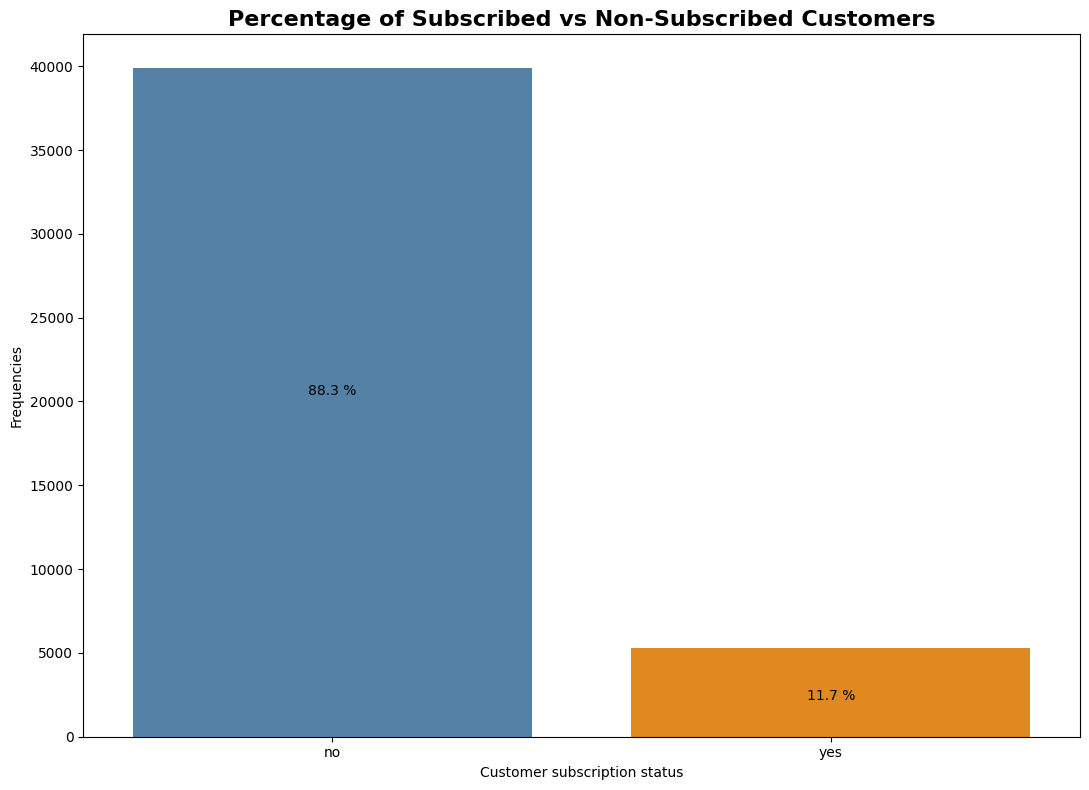

In [12]:
# save list of the count values and percentage values
# for annotate later
count_values = table_print['count'].tolist()
percentage_values = table_print['percentage'].tolist()

fig = plt.figure(figsize = (11, 8)) # set figure size

# looping for data label
for i in range(len(count_values)):
    
    # hard-coded coordinate text for each i
    if i == 0: # for 'no'
        xy = (i, count_values[i]//2)
    else: # for 'yes'
        xy = (i, count_values[i]//3)

    plt.annotate(
        text = percentage_values[i], # show percentage on text
        xy = xy, # coordinate text as above specified
        xytext = (0, 5),
        textcoords = 'offset points',
        ha = 'center'
    )

sns.countplot(x='y', data=df, 
              palette=['steelblue', 'darkorange'], # to differentiate colors
              hue='y', # to prevent seaborn warning for using palette
              legend=False) # to prevent seaborn warning for using palette but not as a legend

plt.xlabel('Customer subscription status') # set x label
plt.ylabel('Frequencies')
plt.title('Percentage of Subscribed vs Non-Subscribed Customers', fontweight='bold', fontsize=16, y=1)

plt.tight_layout()
plt.show()

By the plot above we can see that from this historical campaign calls dataset, most values are customer who ended up not subscribed a term deposit products. There are 88.3 % from 45195 records (after duplicates data removed), which **39906 customers** that ended up as non-subscribed customers. On other hand there are 11.7 % from 45195 customers, which **5289 customers** that ended up as a **subscriber** of a term deposit from this dataset. 

From this information we know that our target variable `y` is imbalanced, so we cannot use **accuracy** as metric evaluation later on modeling process. We can also note that from this information, the goal for this project is by when later use the model prediction, the marketing resources can be more effective. Because after use the prediction model, the targeted customer that will be called are more potential customers that likely to subscribe, rather than using much resources by reach all customers without knowing potential prediction.

## 2. How is the distribution of subscribed vs non-subscribed customers for each marital status type ?

To answer this question, we must group the data by `marital` and `y` then calculate each frequencies:

In [13]:
# assign to the new dataframe
marital_df = df.groupby(['marital', 'y'])['y'].count().reset_index(name='frequencies')

# show the dataframe
marital_df

,marital,y,frequencies
0,divorced,no,4585
1,divorced,yes,622
2,married,no,24453
3,married,yes,2755
4,single,no,10868
5,single,yes,1912


From the table dataframe above, we can see on the plot as below:

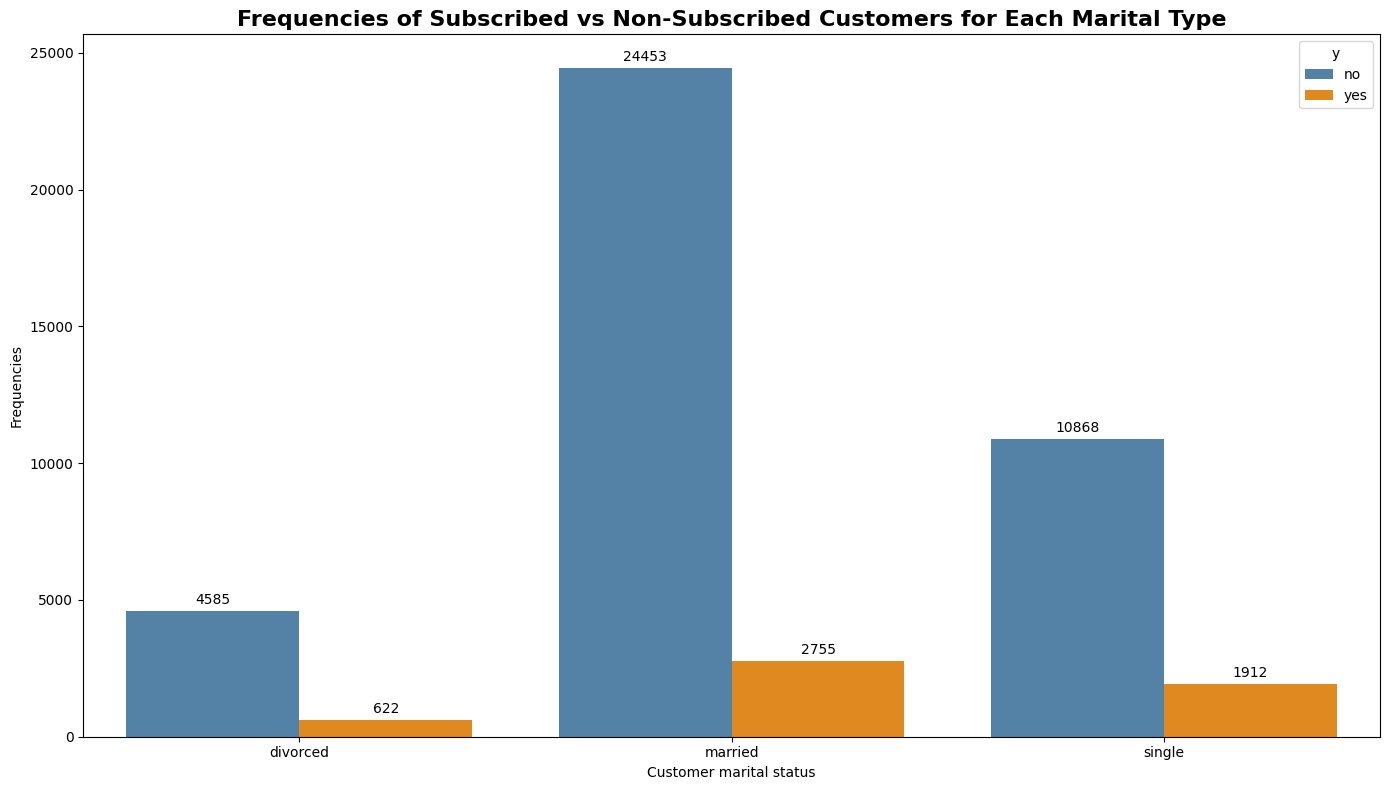

In [14]:
# save the count values for annotate later
count_values = marital_df['frequencies'].tolist()

# set x_positions hardcoded
# width bar 0.4 and space from each marital 0.6
x_positions = [-0.2, 0.2, # divorced
               0.8, 1.2, # married
               1.8, 2.2] # single

fig = plt.figure(figsize = (14, 8)) # set figure size

# looping for data label
for i in range(len(count_values)):
    
    # hard-coded coordinate text for each i
    xy = (x_positions[i], count_values[i]) # show on top

    plt.annotate(
        text = count_values[i], # show frequencies on text
        xy = xy, # coordinate text as above specified
        xytext = (0, 5),
        textcoords = 'offset points',
        ha = 'center'
    )

# seaborn bar plot
sns.barplot(data = marital_df, x = 'marital', y = 'frequencies',
            palette=['steelblue', 'darkorange'], # to differentiate colors
            hue='y'), # to prevent seaborn warning for using palette

plt.xlabel('Customer marital status', y = 1) # set x label
plt.ylabel('Frequencies')
plt.title('Frequencies of Subscribed vs Non-Subscribed Customers for Each Marital Type', fontweight='bold', fontsize=16, y=1)

plt.tight_layout()
plt.show()

Based on the plot above, we can observe the distributions of subscribed and non-subscribed customers for each marital status. There are **24453 customers** with **married** marital status who ended up **not subscribed** to a term deposit products, from total 27208 customers (by adding 24453 and 2755). For the other marital type, there are **10868 customers** with **single** marital status which ended up **not subscribed** to a term deposit products from total 12780 customers (by adding 10868 and 1912). Lastly, there are **4585 customers** with **divorced** marital status who ended up **not subscribed** to a term deposit products from total 5207 customers (by adding 4585 and 622).

The patterns for each marital type are similar with previous overall frequency distribution of subscription status, where there are more customers that ended up non-subscribed (`y = no`) compare with subscribed. However, from the bar plot above among all three marital categories, married customers which the largest group in terms total data also by the **non-subscribed customers ratio**. This indicates that the `marital` show some relationship with the target variable `y`, that we will need check further on modeling process later on **Feature Selection** section. We can also note that, the gap between subscribed and non-subscribed relatively large, which suggests **`marital` alone** may **not a strong feature to be a predictor** variable. Therefore, this feature should be evaluate further with combination other features and be checked in **Feature Selection** section.

## 3. Highest frequencies of clients contacted date of the year

To answer this question, we need to concatenate `day` and `month` as date of the year (which we do not know what year from the data source) as a new column. This column will not be used for future modeling, only to visualize and answer EDA question. For example, we use year 1900 on below code just to visualize later what date and month of the year that clients most contacted from historical data.

In [15]:
# create separate data only use for EDA
df_1 = df.copy()[['day', 'month']] # only these 2 columns

# for example we use year 1900
# this will not use to the model because we do not know exact year for each records
year = 1900

# map the month to number
month_number = {
    'jan' : 1, 'feb' : 2, 'mar' : 3, 'apr' : 4,
    'may' : 5, 'jun' : 6, 'jul' : 7, 'aug' : 8,
    'sep' : 9, 'oct' : 10, 'nov' : 11, 'dec' : 12
}

# create new column month that filled with number
df_1['month_num'] = df_1['month'].map(month_number)

# create date column
df_1['date'] = pd.to_datetime({'year' : year, 
                              'month' : df_1['month_num'], 
                              'day' : df_1['day']})

# inspect new column
df_1['date']

0       1900-05-05
1       1900-05-05
2       1900-05-05
3       1900-05-05
4       1900-05-05
           ...    
45190   1900-11-17
45191   1900-11-17
45192   1900-11-17
45193   1900-11-17
45194   1900-11-17
Name: date, Length: 45195, dtype: datetime64[ns]

After that, we will create series of frequencies with `value_counts()` method:

In [16]:
date_frequencies = pd.DataFrame([
    df_1['date'].value_counts().sort_index() # the date sorted ascending
    ]).T # transpose

# inspect the result
date_frequencies

,count
date,
1900-01-06,2
1900-01-07,4
1900-01-08,5
1900-01-11,12
1900-01-12,22
...,...
1900-12-27,1
1900-12-28,16
1900-12-29,13


Then we plot this date and each frequencies of contacted clients:

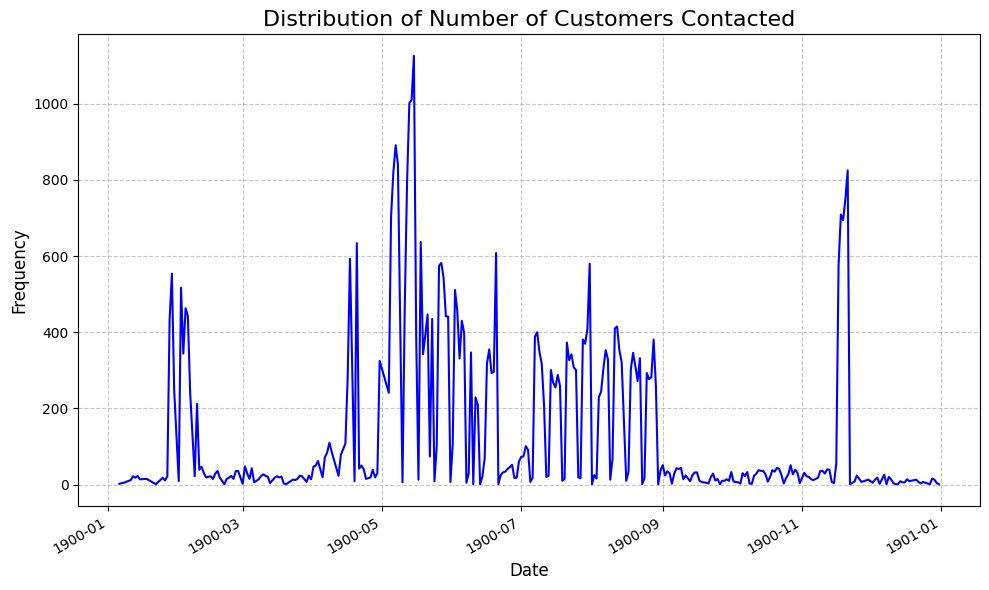

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(date_frequencies.index, date_frequencies['count'], linestyle='-', color='b')
ax.set_title('Distribution of Number of Customers Contacted', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Earlier we knew that year 1900 above solely used to visualize the frequencies of each date and month of the year (so the year can be different for each records in actual). By above plot we have information that customers more frequently contacted on month May and June (not specific on the same year, but we know the patterns), reached more than 1000 calls. While on other months usually on the level 500 - 600 calls, but much less contacted on March, September, October, and December that only less than 100 calls. However, it is also noticeable that there is sudden spike on November, that in total (for all years from original data) there are more than 800 calls.

From the exploratory analysis above, we observed the campaign activities most frequent on May and June. Although this visualization does not represent the real timeline of events, because may the data are collected from different year, it provides useful insights into marketing operational behaviour. Since the data originally not include reliable year-level information and the order of observations not informed as time progression, this pattern will not be directly incorporated into the predictive model. Hence, we cannot predict with **time series model** in this case, the `day` and `month` features will be treated as **categorical variables** for **supervised classification** model instead. In the next section, we will proceed to the data preprocessing and modeling phase, along with other features from original dataset.

## 4. Does past campaign informations (`pdays`, `previous`, and `poutcome`) have strong association with target ?

First, if we see the data frequencies if `pdays = -1`, that from the dataset source means the client was not previously contacted (previous of the current historical data timeline):

In [18]:
df[
    (df['pdays'] == -1)
][['previous', 'poutcome']].value_counts()

previous  poutcome
0         unknown     36938
Name: count, dtype: int64

Customers with `pdays = -1` consistent have no previous contact, so the number of this customer contacted is 0 (`previous`) and the outcome is unknown (`poutcome`) because no outcome. For all of these customer, mean there is no previous information of the customer from historical dataset (that means no previous historic data, previous of historical data timeline on the dataset).

If we see from 36938 customers that previously have not contacted (previous of the historical dataset timeline):

In [19]:
df[
    (df['pdays'] == -1)
][['previous', 'poutcome', 'y']].value_counts()

previous  poutcome  y  
0         unknown   no     33554
                    yes     3384
Name: count, dtype: int64

Above output shows from 36938 customers that previously not contacted, the result where customer subscribed only 3384 out of 36938 customers. This mean from historical campaign record, the percentage rate of new customer approached and successfully subscribed is about 9%. By development of this machine learning model to predict customer will subscribe by this past historical data, the hope is to increase this percentage.

Next, if we see the association of each of these 3 features with target variable `y`:
> Note that, in this **EDA** section we use all dataset `df`. However on **Feature Selection** when modeling process we obviously will use train-set only

In [20]:
# define function to correlate variables with default
def compute_phik_correlation(dataframe, columns, target):
    subset = dataframe[columns]
    correlation_matrix = subset.phik_matrix()
    return correlation_matrix[target]

# compute Phi-K correlation for each set of columns and print
correlation = compute_phik_correlation(
    df[['pdays', 'previous', 'poutcome', 'y']],
    df[['pdays', 'previous', 'poutcome', 'y']].columns.to_list(),
    target=['y']
)

# Print result
print(correlation)

interval columns not set, guessing: ['pdays', 'previous']
                 y
pdays     0.250736
previous  0.015868
poutcome  0.461560
y         1.000000


> **References** to use Phi-K correlation value:
> - [Baak, M., Koopman, R., Snoek, H., & Klous, S. (2019)](https://arxiv.org/pdf/1811.11440)
> - [phik-documentation](https://phik.readthedocs.io/_/downloads/en/stable/pdf/)

By above output, Phi-K correlation value shows that `poutcome` has the strongest association with the target, from these 3 features of past campaign information (past of current historical data timeline). We can also see that `pdays` have Phi-K correlation value 0.25, lower than `poutcome` but not so low. However, it is noticeable that `previous` have the lowest and low value of Phi-K correlation value that almost 0, indicates **no association** with the target variable.

Although the above result, we check information of all of the dataset `df` just for **EDA** purposes. The real association check of all features will be done on **Feature Selection** section when modeling, with only train data. The purpose is to avoid information leakage and ensure feature selection based solely on training data, and the test data follow behavior of **unseen data** and as correct benchmark for model evaluation.

## 5. Distribution of numerical features (`age`, `balance`, `campaign`, `pdays`, and `previous`)

If we see the distribution plot of each numerical features:

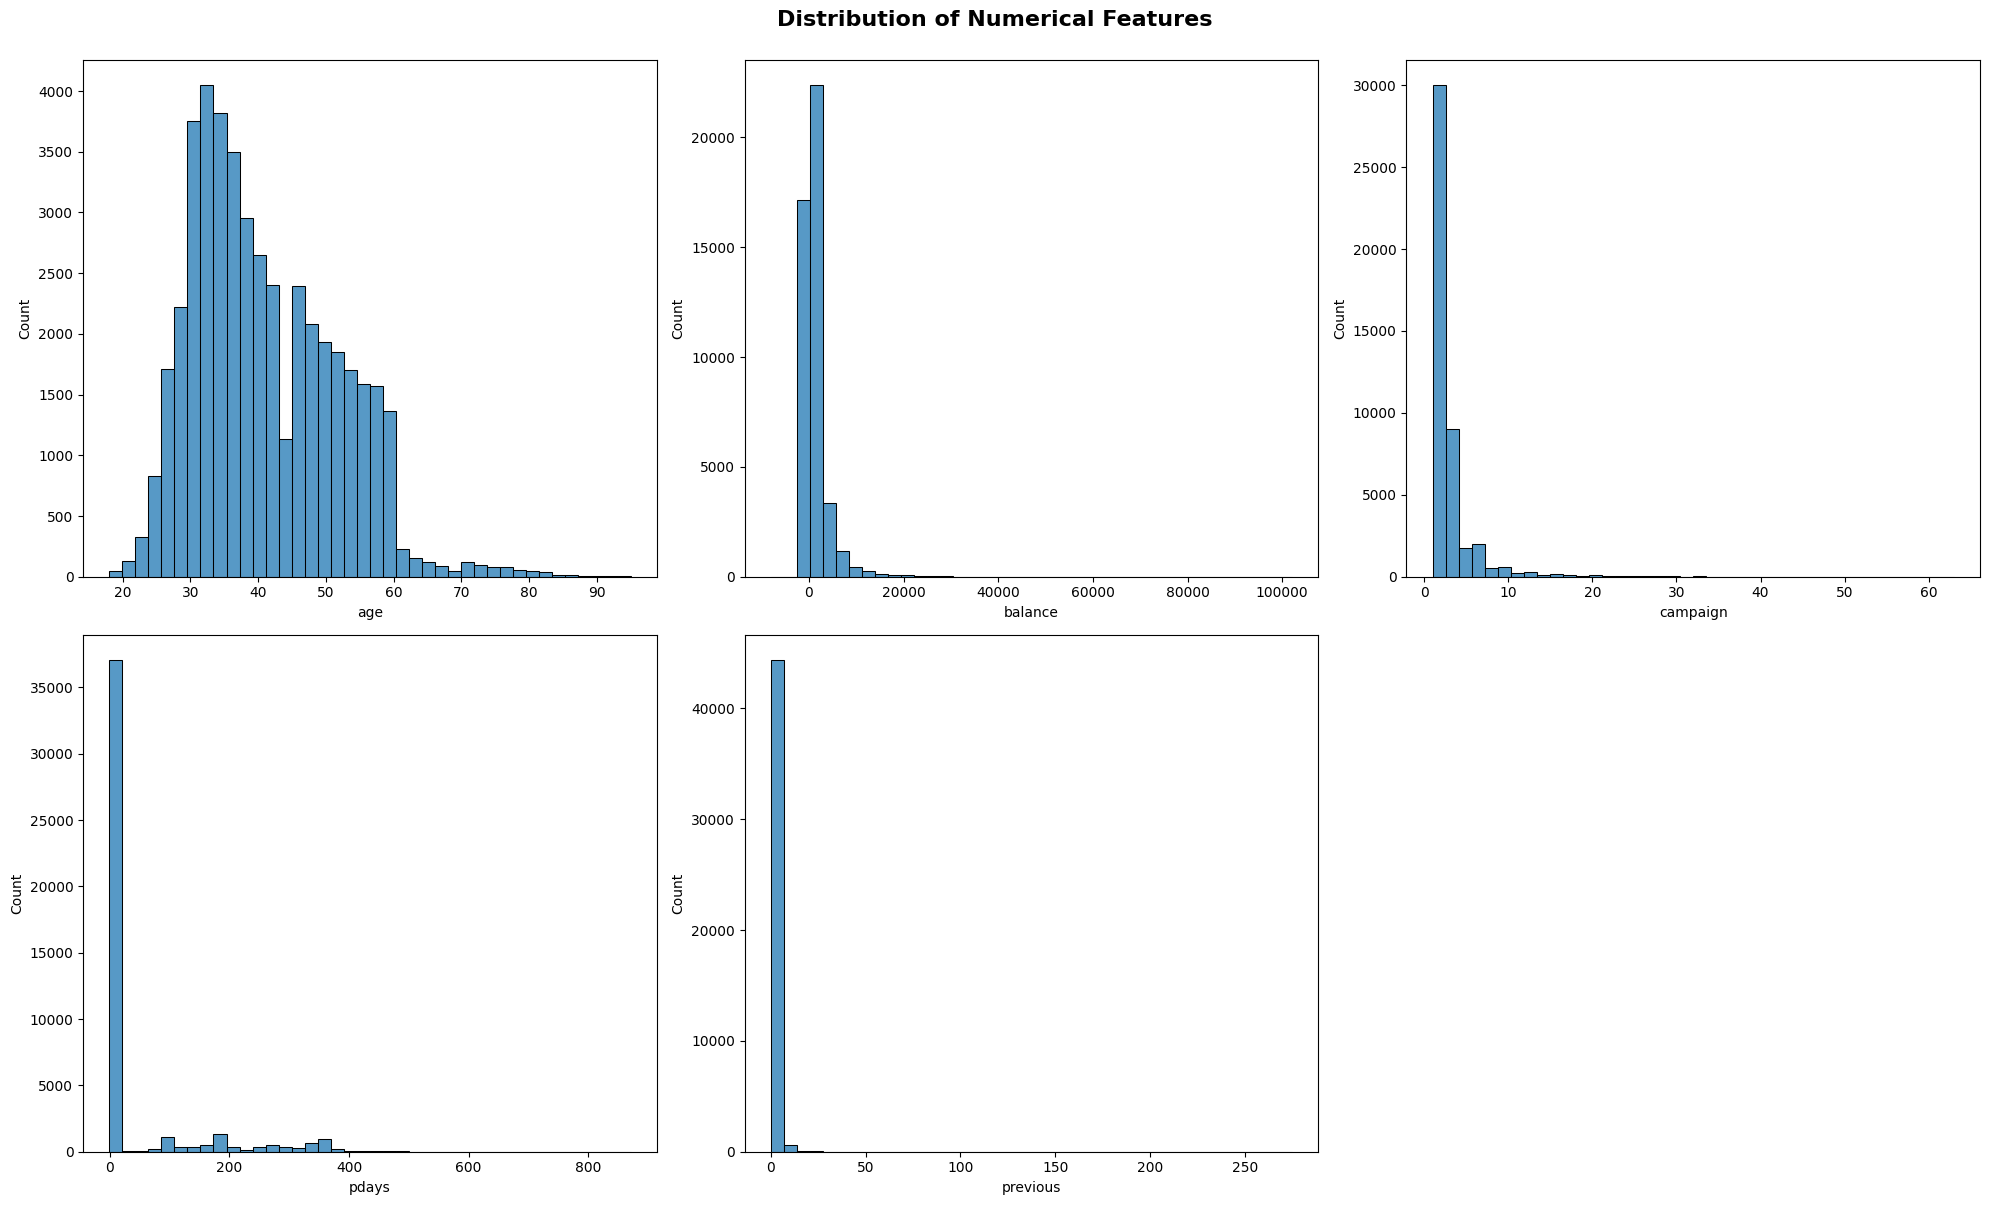

In [21]:
num_cols = ['age', 'balance', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (20, 12)) # create 2x3 subplots

# initial value for axes
nrow = 0
ncol = 0

for col in num_cols:

    # set axes
    ax = axes[nrow, ncol]

    # histogram plot to see distribution
    # use df since on EDA section
    sns.histplot(df[col], bins = 40, ax = ax)
    ax.set_xlabel(col)

    ncol += 1 # increase the ncol

    # ncol should only 0, 1, or 2
    # if after increment earlier reached 3
    if ncol == 3: 
        ncol = 0 # reset to 0
        nrow += 1 # next row

# turned off unused axis
axes[1, 2].axis('off')

# display the plot and styling
fig.suptitle('Distribution of Numerical Features', fontsize = 16, fontweight = 'bold', y = 1)
plt.tight_layout()
plt.show()

It is noticeable that all of the numerical variable above have **positive skew** distribution based on historical dataset. Only column `age` that the distribution *may* look not extremely skew, but the other variables *indicates* have **extreme positive skew distribution**. Regarding normality, if we check further with D'Agostino K-Squared Test to check normality:
> **H0: the data follows normal distribution** <br>
> **H1: the data does not follows normal distribution**

In [22]:
skew_list = []
pvalue_list = []

for col in num_cols:
    # skewness value
    skew = df[col].skew()

    # d'agostino statistical hypothesis test
    pvalue = stats.normaltest(df[col]).pvalue
    
    # add to the list
    skew_list.append(skew)
    pvalue_list.append(pvalue)

table_print = pd.DataFrame({
    'Skewness value' : skew_list,
    'P-value' : pvalue_list
})
table_print.index = num_cols # change index
table_print

,Skewness value,P-value
age,0.684684,0.0
balance,8.359274,0.0
campaign,4.898646,0.0
pdays,2.615075,0.0
previous,41.840198,0.0


Since all p-value < 0.05, we reject null hypothesis for all numerical columns earlier. That means all numerical features are **not normally distributed** on this historical dataset. Based on the skewness value, only column `age` that is **moderate positive skew**, the other are **extreme positive skew**. Although on the modeling process later we need to based on **training set only**, this behavior should be follows since train-test randomly split. The process to see distribution of all numerical dataset based on **full historical dataset** is complete. We only done for **EDA purposes**, and will do re-checking for modeling purposes later with only check the distribution on the training set.

## 6. Are there numerical features that need logarithmic transformation ?

Note that the **extreme positive** skew distribution earlier are too extremely skew, there will be too many data resided as **outliers** later. We may apply re-shaping to handle this by **natural logarithmic transformation**. We do not need to apply to `age` since the distribution plot earlier already have the shape. We also cannot apply to the variable `balance` because earlier we known that there are many negative values (consider customers who currently in the state of debt). Hence, for the other three numerical variables, if we see the result:
> We will do log-transformation procedure of reshaping process of numerical variable for later in the section **Outliers Handling**, one of transformation technique that effective to normalize numerical variable. References: <br>
> - [Kaggle: logarithm-is-effective-at-normalizing](https://www.kaggle.com/code/ryanholbrook/creating-features) <br>
> - [Benefit-closeness-to-normality](https://towardsdatascience.com/logarithmic-transformation-for-beginners-99488b8951e3/)

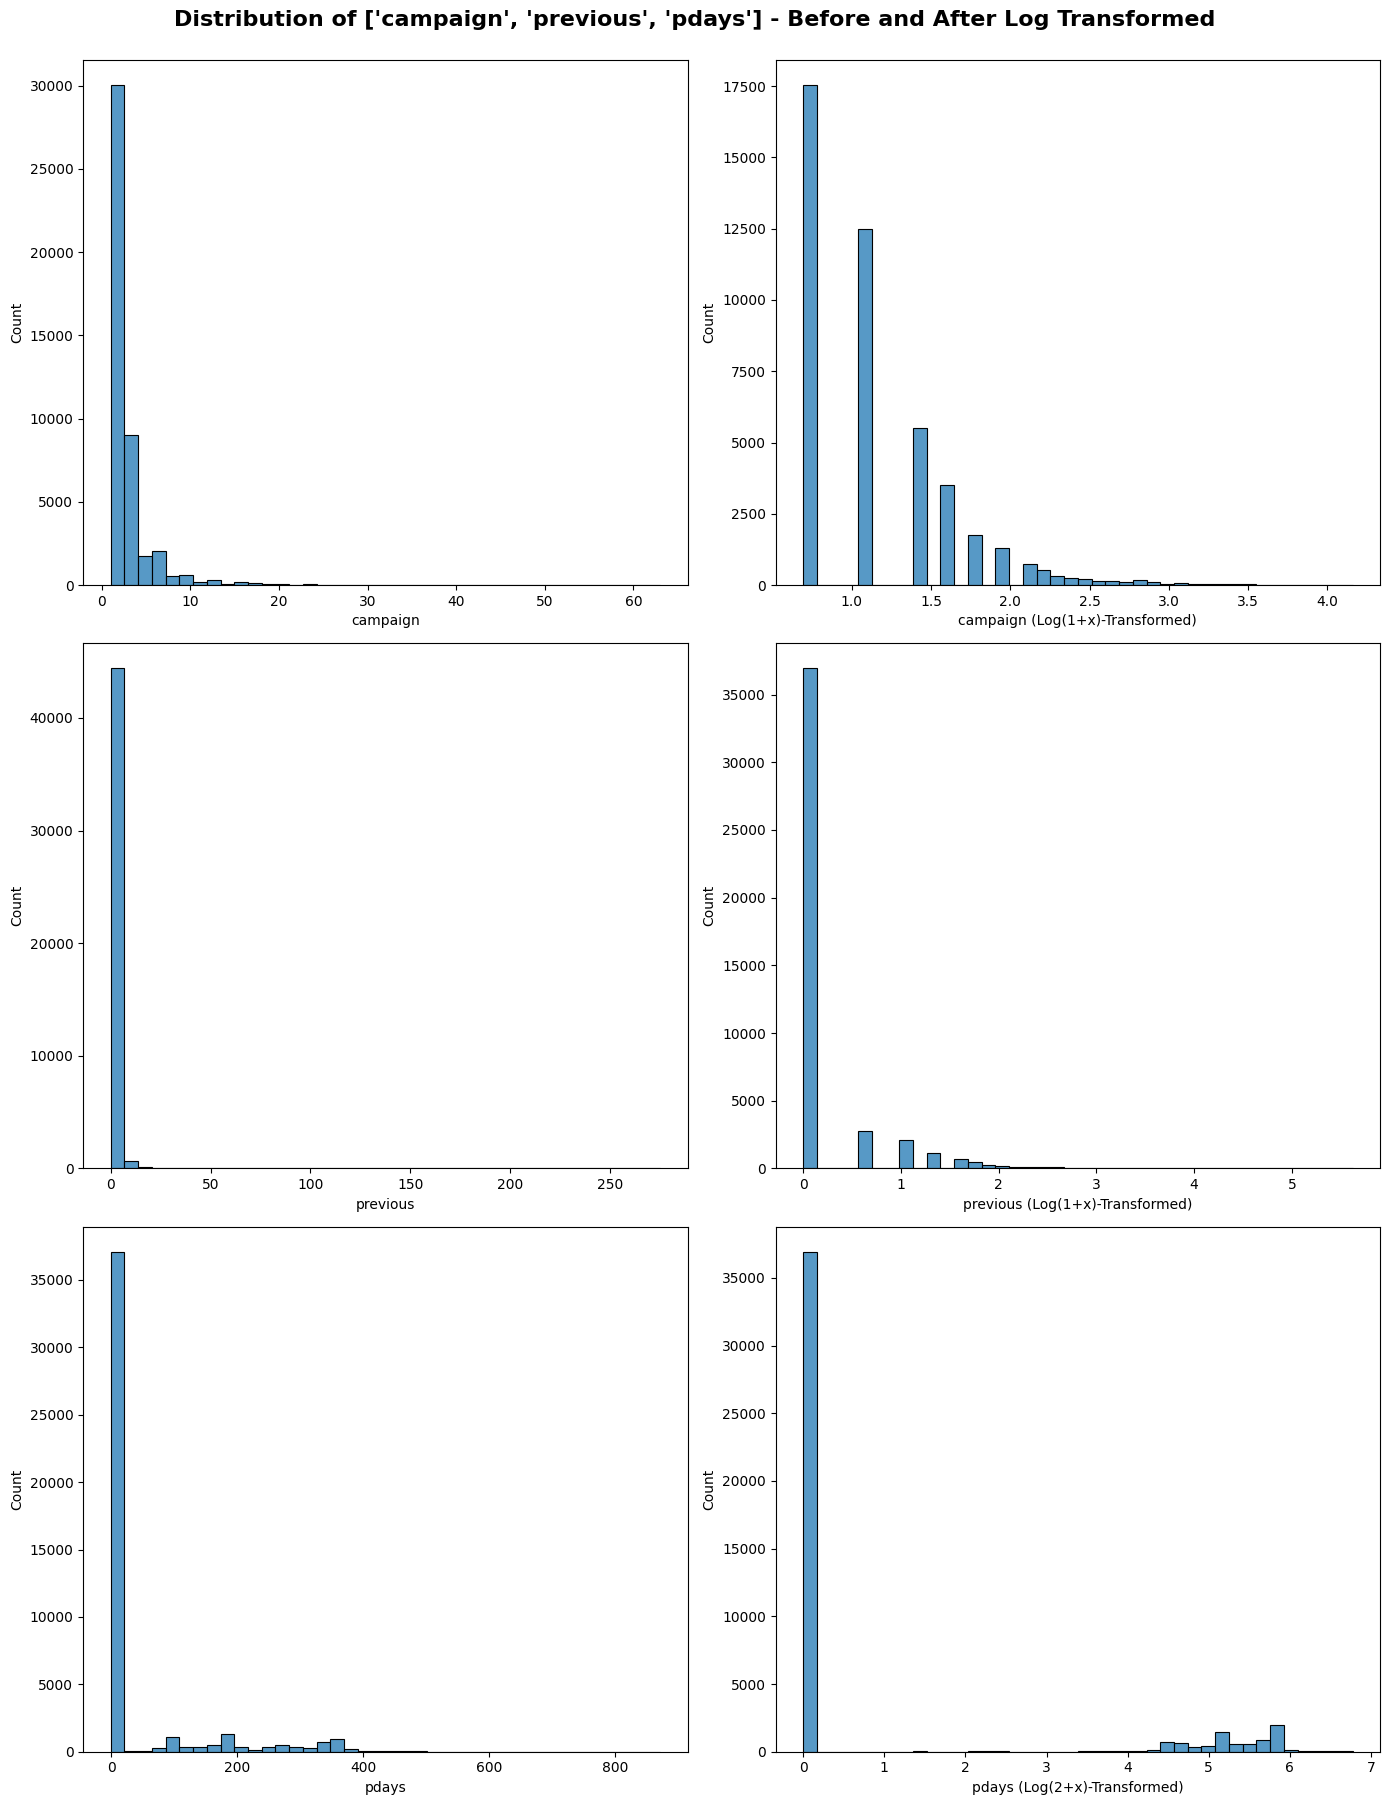

In [23]:
log1p_cols = ['campaign', 'previous']
log2p_cols = ['pdays'] # since pdays there is -1 values, need log(2+x) instead of log(1+x)

fig, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (14, 18)) # create 3x2 subplots

log_cols = log1p_cols + log2p_cols

for i in range(len(log_cols)):
    col = log_cols[i]

    # left plot - original
    sns.histplot(df[col], bins = 40, ax = axes[i, 0])
    axes[i, 0].set_xlabel(col)

    # right plot - log-transformed
    # log(2+x) for pdays (not in log1p_cols)
    sns.histplot(np.log1p(df[col]) if col in log1p_cols else np.log1p(df[col] + 1), 
                 bins = 40, ax = axes[i, 1])
    axes[i, 1].set_xlabel(
        f'{col} (Log(1+x)-Transformed)' if col in log1p_cols else f'{col} (Log(2+x)-Transformed)'
    )

# display the plot and styling
fig.suptitle(f'Distribution of {log_cols} - Before and After Log Transformed', fontsize = 16, weight = 'bold', y = 1)
plt.tight_layout()
plt.show()

By above result, after re-shaping log-transformed log(1+x) (except for `pdays` with log(2+x) since there are many -1 values) the distributions are more stable and outliers more handled. However, if we see further on previous plot, even after log-transformation, the distribution more focus on 1 part that is **0** after log-transformation (before log-transformation, `pdays` focus on -1 value, while `previous` focus on 0 value). That means both of these columns **zero-inflated** columns.

In [24]:
## zero-inflated percentage print
zero_inflated = ['pdays', 'previous']
top_most_values = []
percentage_top = []

for col in zero_inflated:
    # add to the list
    top_most_values.append(df[col].value_counts().index[0]) # top most values
    
    top_freq = df[col].value_counts().iloc[0] # top most frequencies
    percentage = top_freq * 100 / df.shape[0]

    # add to the list
    percentage_top.append(f'{percentage:.2f} %') 

table_print = pd.DataFrame({
    'Top most value' : top_most_values,
    'Percentage in data' : percentage_top
})
table_print.index = zero_inflated # change index
table_print

,Top most value,Percentage in data
pdays,-1,81.73 %
previous,0,81.73 %


By above result we have information there **inflated** focus to 1 values for both these numerical columns `pdays` and `previous`. From earlier information on **EDA** section 2, we have information that both of these columns are explain past campaign information. Later we will try to re-apply this process in **Outliers Handling** section, and explore further to see what to do in modeling process. For current exploratory data analysis in this section, we found that the logarithmic transformation made distribution of `campaign` more stable and can be used for this variable with further handling on **Outliers Handling** section, **but for `pdays` and `previous`** need **further inspection** regarding **zero-inflated** behavior.

# v. Feature Engineering

## 1. Split X (features) and y (target)

Recall that from **Data Loading** section we ended up have 45195 rows and 16 columns (include the target) from the dataset `df`, we split features and target:

In [25]:
# define the target
y = df['y']

# define the features
X = df.drop('y', axis = 1) # drop column-wise

print(f'The shape of features from dataset is: {X.shape}')
print(f'The shape of target from dataset is: {y.shape}')

The shape of features from dataset is: (45195, 15)
The shape of target from dataset is: (45195,)


Above process, we already split features and target from the dataset. For now we have 15 features on `X` and 1 target `y`. We can also see that our target variable is categorical variable and **still not encoded yet**:

In [26]:
# check the target
y.value_counts()

y
no     39906
yes     5289
Name: count, dtype: int64

We will encode later in **Feature Encoding** process along with encode other categorical features. Since we are more concern a customer that will subscribe from this historical dataset, if we check the percentage of **yes** in the data:

In [27]:
value_no = y.value_counts()[0] # frequency of no
value_yes = y.value_counts()[1] # frequency of yes

print(f'The percentage of value "yes" on target variable is : {(value_yes*100)/(value_yes+value_no):.2f}%')

The percentage of value "yes" on target variable is : 11.70%


By above output, we can see that the percentage of value "yes" in this historical dataset is only 11.70%. Many of customers ended up not subscribed rather than successfully subscribe by phone calls campaign. Since the target variable in this data is **Imbalanced**, we will not use **Accuracy** for model evaluation later. Also, we may need to change **threshold** later at **Modeling Evaluation** section because of this imbalanced data of target variable.

## 2. Split Numerical Columns an Categorical Columns

If we check all columns on the features:

In [28]:
# check columns on features
print(X.columns, '\n') # new line to separate

# check based on info method to recheck data type that earlier check on data loading
X.info()

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome'],
      dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45195 entries, 0 to 45194
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45195 non-null  int64 
 1   job        45195 non-null  object
 2   marital    45195 non-null  object
 3   education  45195 non-null  object
 4   default    45195 non-null  object
 5   balance    45195 non-null  int64 
 6   housing    45195 non-null  object
 7   loan       45195 non-null  object
 8   contact    45195 non-null  object
 9   day        45195 non-null  object
 10  month      45195 non-null  object
 11  campaign   45195 non-null  int64 
 12  pdays      45195 non-null  int64 
 13  previous   45195 non-null  int64 
 14  poutcome   45195 non-null  object
dtypes: int64(5), object(10)
me

By above output we can separate numerical and categorical columns as below:
- Numerical = [`age`, `balance`, `campaign`, `pdays`, `previous`]
- Categorical = [`job`, `marital`, `education`, `default`, `housing`,`loan`, `contact`, `day`, `month`, `poutcome`]

Earlier we known that `day` is **categorical ordinal** rather than numerical features, even if the value is integer values. Split numerical and categorical features based on above separation:

In [29]:
# split
num_cols = ['age', 'balance', 'campaign', 'pdays', 'previous']
cat_cols = ['job', 'marital', 'education', 'default', 'housing',
            'loan', 'contact', 'day', 'month', 'poutcome']

print(f'Number of numerical features: {len(num_cols)}')
print(f'Number of categorical features: {len(cat_cols)}')

Number of numerical features: 5
Number of categorical features: 10


We have split the 15 features into 5 numerical features and 10 categorical features.

## 3. Cardinality Check and Handling for Categorical Columns

For each categorical features, we need to check the cardinality:

In [30]:
# loop for categorical columns
for col in cat_cols:
  print(f'Number of unique values of "{col}" is {X[col].nunique()}')

Number of unique values of "job" is 12
Number of unique values of "marital" is 3
Number of unique values of "education" is 4
Number of unique values of "default" is 2
Number of unique values of "housing" is 2
Number of unique values of "loan" is 2
Number of unique values of "contact" is 3
Number of unique values of "day" is 31
Number of unique values of "month" is 12
Number of unique values of "poutcome" is 4


Note that all categorical features have low to moderate cardinality (lower than 10), **except** column `job`, `day`, and `month`. If we see further unique values of these features:

In [31]:
start = True # separate line except at start

for col in ['job', 'day', 'month']:

    if not start:
        print() # separate line
    
    if col != 'job': # only job that nominal

        # since month still on the form "jan", "feb", cannot be sorted before encoding process
        if col != 'month':
            print(X[col].value_counts().sort_index()) # sort index for ordinal

        else: # if month, reorder the index manually for now (since not encoded yet)
            print(X[col].value_counts().reindex([
                'jan', 'feb', 'mar', 'apr', 'may', 'jun',
                'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
            ]))
    
    else:
        print(X[col].value_counts()) # for nominal

    start = False

job
blue-collar      9730
management       9451
technician       7593
admin.           5171
services         4152
retired          2263
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

day
1      322
2     1293
3     1079
4     1445
5     1910
6     1932
7     1816
8     1842
9     1560
10     524
11    1479
12    1603
13    1585
14    1847
15    1703
16    1415
17    1939
18    2308
19    1756
20    2752
21    2021
22     901
23     939
24     447
25     840
26    1034
27    1121
28    1829
29    1744
30    1566
31     643
Name: count, dtype: int64

month
jan     1403
feb     2649
mar      477
apr     2932
may    13764
jun     5341
jul     6892
aug     6236
sep      579
oct      738
nov     3970
dec      214
Name: count, dtype: int64


For column `job` we may handle the high cardinality by picked only top 5 (based on frequencies), and the rest will be grouped (that means will change the value) into `'other'`, which ended up reduced the cardinality into 6. 

While for column `day` and `month` since **ordinal** categorical features, we may grouped based on the order as below:
- `day` : grouped into 5 groups of day of the month → [`1 - 6`, `7 - 12`, `13 - 18`, `19 - 24`, `25 - 31`], reduced the cardinality into 5
- `month` : grouped into 4 groups of month of the year → [`jan - mar`, `apr - jun`, `jul - sep`, `oct - dec`], reduced the cardinality into 4

### For column `job`:

In [32]:
# recheck top 5 from column job
X['job'].value_counts()[:5]

job
blue-collar    9730
management     9451
technician     7593
admin.         5171
services       4152
Name: count, dtype: int64

In [33]:
# define function for grouping
def job_top5_grouping(df, col='job'):
    
    # list the top 5 from such column
    job_top5 = ['blue-collar', 'management', 'technician', 'admin.', 'services']

    # change other values into 'other'
    df.loc[~(df[col].isin(job_top5)), col] = 'other'

# group the column `job`
job_top5_grouping(X, 'job')

# recheck all the value_counts()
X['job'].value_counts()

job
blue-collar    9730
management     9451
other          9098
technician     7593
admin.         5171
services       4152
Name: count, dtype: int64

By above result, we have reduced the cardinality of column `job` into 6.

### For column `day`:

In [34]:
# we will use pd.cut to replace column `day` value on X
# with string '1 - 6', '7 - 12', '13 - 18', and so on
# by default on pd.cut method argument right = True
def day_binning(series):
    return pd.cut(
        series,
        # below process since right == True
        # will group and replace the value as:
        # (0, 6] (or the same as [1, 6] in this case) for '1 - 6'
        # (6, 12] for '7 - 12' (this is the same with [7, 12])
        # and so on... until
        # (25, 31] for '25 - 31' (this is the same with [25, 31])
        bins=[0, 6, 12, 18, 24, 31],
        labels=['1 - 6', '7 - 12', '13 - 18', '19 - 24', '25 - 31']
    )

# replace column `day`
X['day'] = day_binning(X['day'])

# recheck `day` unique values and frequencies
X['day'].value_counts().sort_index()

day
1 - 6       7981
7 - 12      8824
13 - 18    10797
19 - 24     8816
25 - 31     8777
Name: count, dtype: int64

By above result, we have reduced the cardinality of column `day` into 5.

### For column `month`:

In [35]:
# define function

# use pd.cut to replace column `month` value on X
# with string 'jan - mar', 'apr - jun', 'jul - sep', and 'oct - dec'
# by default on pd.cut method argument right = True
def month_binning(series):

    # map the month to number first
    # same as used in EDA earlier
    month_number = {
        'jan' : 1, 'feb' : 2, 'mar' : 3, 'apr' : 4,
        'may' : 5, 'jun' : 6, 'jul' : 7, 'aug' : 8,
        'sep' : 9, 'oct' : 10, 'nov' : 11, 'dec' : 12
    }

    # map and replace column `month` with number
    series = series.map(month_number)

    return pd.cut(
        series,
        # below process since right == True
        # will group and replace the value as:
        # (0, 3] (or the same as [1, 3] or jan - mar in this case) for 'jan - mar'
        # (3, 6] for 'apr - jun' (this is the same with [4, 6] or apr - jun)
        # (6, 9] for 'jul - sep' (this is the same with [7, 9] or jul - sep)
        # (9, 12] for 'oct - dec' (this is the same with [10, 12] or same as oct - dec)
        bins=[0, 3, 6, 9, 12],
        labels=['jan - mar', 'apr - jun', 'jul - sep', 'oct - dec']
    )

# replace column `month`
X['month'] = month_binning(X['month'])

# recheck `month` unique values and frequencies
X['month'].value_counts().sort_index()

month
jan - mar     4529
apr - jun    22037
jul - sep    13707
oct - dec     4922
Name: count, dtype: int64

By above result, we have reduced the cardinality of column `month` into 4.

After above process, then all cardinality of categorical features for modeling now is 6 or lower:

In [36]:
# recheck cardinality with loop for categorical columns
for col in cat_cols:
  print(f'Number of unique values of "{col}" is {X[col].nunique()}')

Number of unique values of "job" is 6
Number of unique values of "marital" is 3
Number of unique values of "education" is 4
Number of unique values of "default" is 2
Number of unique values of "housing" is 2
Number of unique values of "loan" is 2
Number of unique values of "contact" is 3
Number of unique values of "day" is 5
Number of unique values of "month" is 4
Number of unique values of "poutcome" is 4


## 4. Splitting Dataset (Train-set and Test-set)

After cardinality check, now we can split the dataset for train-set and test-set with `train_test_split`:

In [37]:
# set random_state for instance, to be use for further process
random_state = 35

# split and will use 20% test and 80% train split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = random_state)

# see display of data
print(f'Train size: {X_train.shape}')
print(f'Test size: {X_test.shape}')

Train size: (36156, 15)
Test size: (9039, 15)


## 5. Missing Value Handling

As we check earlier on **Data Loading** process, there are no missing values in this dataset:

In [38]:
# recheck what we earlier check on Data Loading

# check missing values of y_train
print(y_train.isna().sum(), '\n') # new line to separate

# check missing values of y_test
print(y_test.isna().sum(), '\n') # new line to separate

# check missing values of X_train
print(X_train.isna().sum(), '\n') # new line to separate

# check missing values of X_test
print(X_test.isna().sum())

0 

0 

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64 

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64


However, **if there are missing values** on column features later for unseen data (may the future test data or inference data). We may need to prepare for unseen data by add `SimpleImputer` to handle missing values. Hence, we will later use `SimpleImputer` for **pipeline** preprocessing in `ColumnTransformer` later by `SimpleImputer(strategy = 'most_frequent')` for categorical features, and for numerical features we will check the normality first in **Outliers Handling** section, whether by **median** or **mean**.

## 6. Outliers Handling

Note that, the categorical variables are not concerned for outliers handling, and only concern the cardinality on earlier **Cardinality Handling** section. Following what we already found earlier on **EDA question 3** earlier, numerical columns `age`, `balance`, `campaign`, `pdays`, and `previous` are proven not normally distributed by D'Agostino K-Squared test. Only column `age` have **moderate skew** distribution, while the rest are **extreme skew** distribution. If we recheck the result for the train set:

In [39]:
# recheck on train set instead of full dataset df

start = True # to only not print new line on first iteration

for col in num_cols:
    # skewness value
    skew = X_train[col].skew()

    # d'agostino statistical hypothesis test
    pvalue = stats.normaltest(X_train[col]).pvalue

    if not start:
        print() # add new line to separate
    
    print(f'For column {col}:')
    print(f'The skewness value: {skew}')
    print(f'The pvalue: {pvalue}')

    start = False

For column age:
The skewness value: 0.679910857259687
The pvalue: 0.0

For column balance:
The skewness value: 8.716648327550635
The pvalue: 0.0

For column campaign:
The skewness value: 4.856105568290792
The pvalue: 0.0

For column pdays:
The skewness value: 2.6443893699384122
The pvalue: 0.0

For column previous:
The skewness value: 8.131984244594818
The pvalue: 0.0


The results are the same on **EDA** section earlier, all p-value < 0.05, we reject null hypothesis for all numerical columns. It is proven that all numerical features are **not normally distributed**. 

Earlier on **EDA** section also we have information that for `campaign`, `pdays`, and `previous` will be apply **natural logarithmic transformation** for re-shaping to more stabilize the outliers. If we see the plot before and after log-transformed earlier and see the resulted skewness after transformation:

For column campaign (Log(1+x)-Transformed):
The skewness value: 1.3231316863878024
The pvalue: 0.0

For column previous (Log(1+x)-Transformed):
The skewness value: 2.5090986482145072
The pvalue: 0.0

For column pdays (Log(2+x)-Transformed):
The skewness value: 1.7079593218928868
The pvalue: 0.0


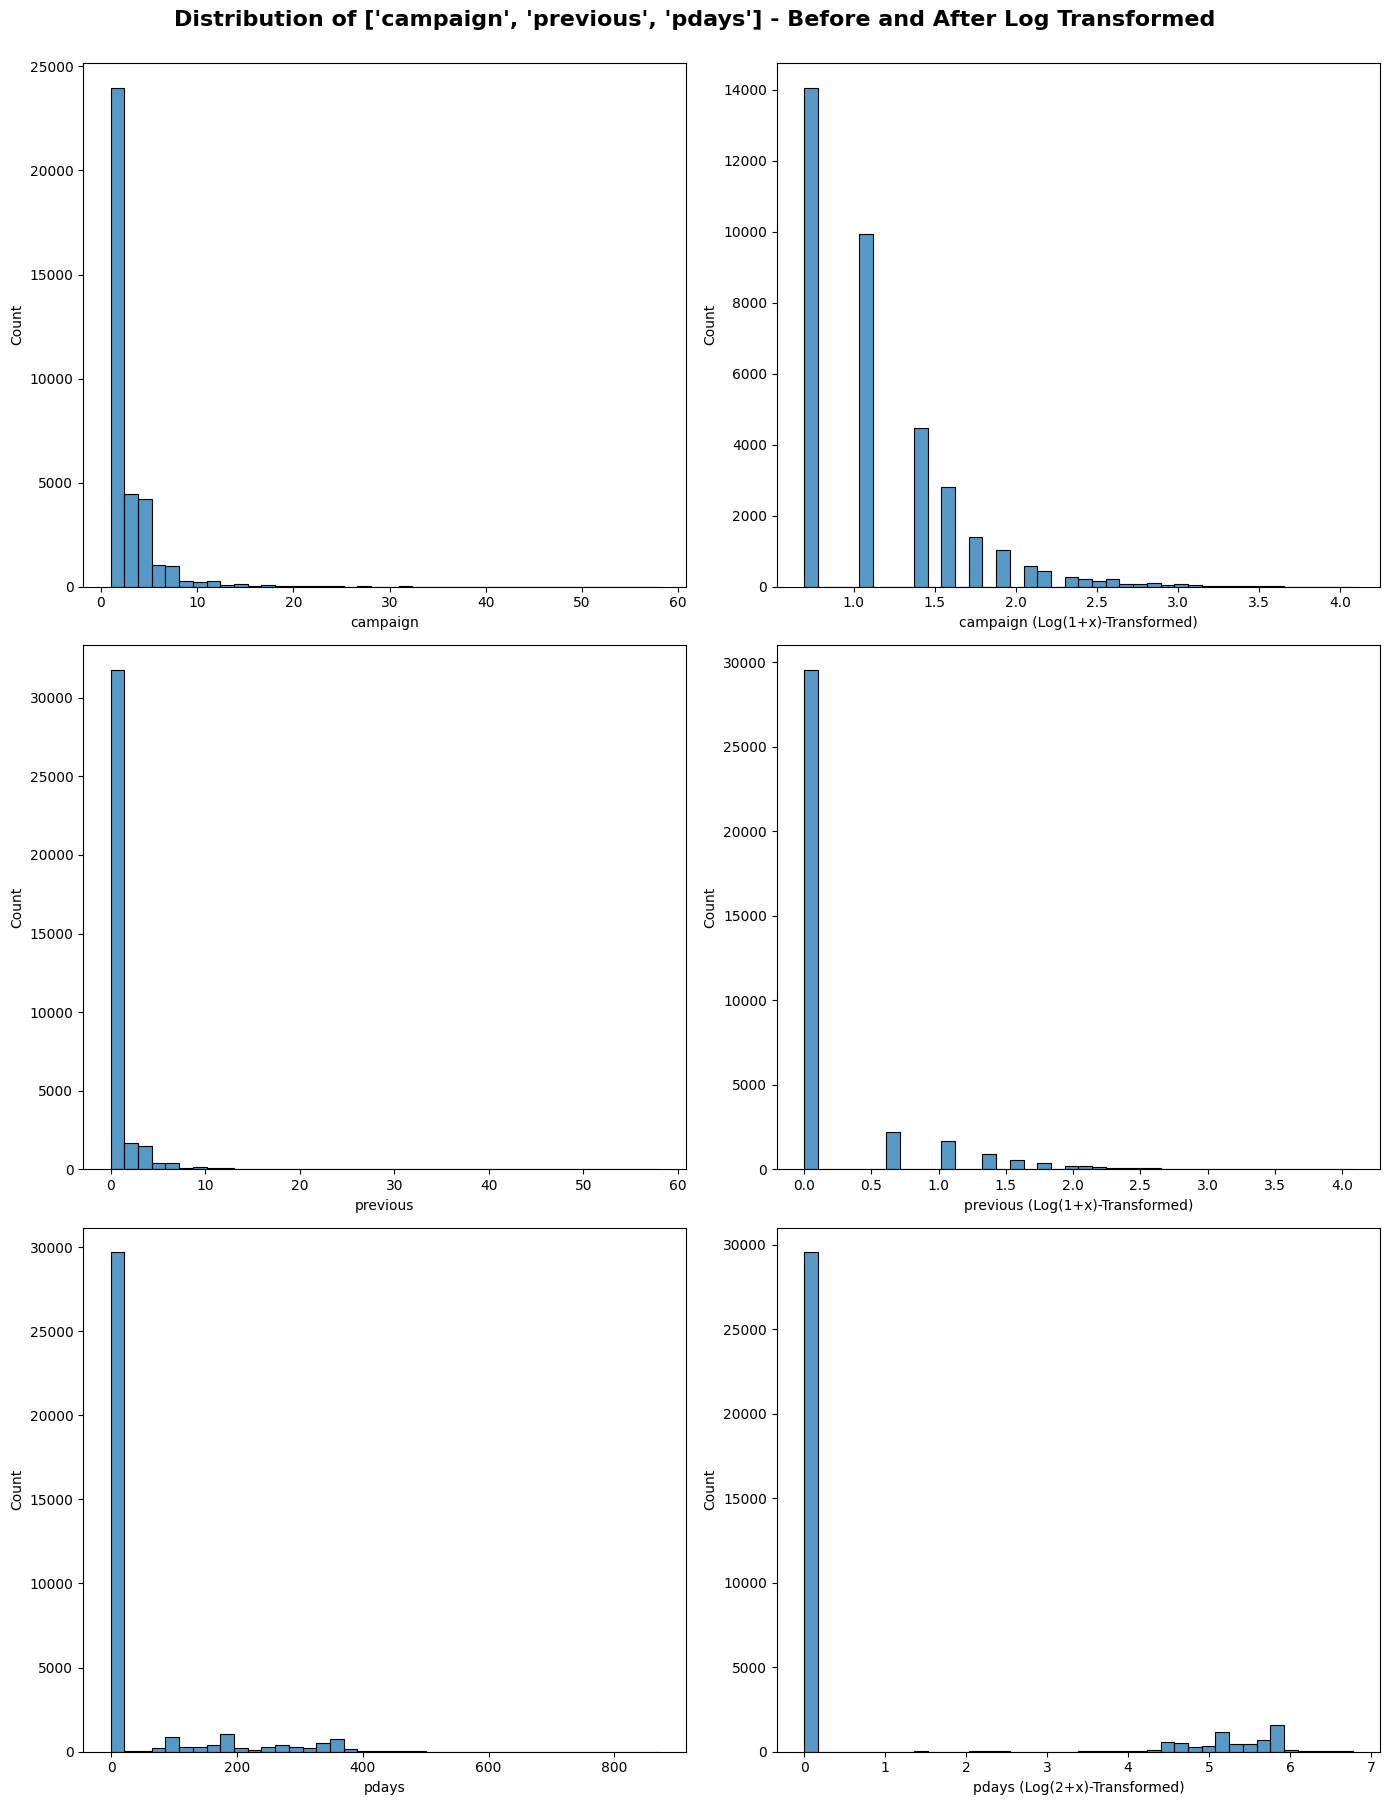

In [40]:
log1p_cols = ['campaign', 'previous']
log2p_cols = ['pdays'] # since pdays there is -1 values, need log(2+x) instead of log(1+x)

log_cols = log1p_cols + log2p_cols

# recheck the skewness if apply log-transformed
start = True # to only not print new line on first iteration

for col in log_cols:
    # skewness value
    skew = (
        np.log1p(X_train[col]) if col in log1p_cols else np.log1p(X_train[col] + 1) # log(2+x) for pdays which is not in log1p_cols
    ).skew()

    # d'agostino statistical hypothesis test
    pvalue = stats.normaltest(
        np.log1p(X_train[col]) if col in log1p_cols else np.log1p(X_train[col] + 1) # log(2+x) for pdays which is not in log1p_cols
    ).pvalue

    if not start:
        print() # add new line to separate
    
    if col in log1p_cols:
        print(f'For column {col} (Log(1+x)-Transformed):')
    else: # for pdays
        print(f'For column {col} (Log(2+x)-Transformed):')

    print(f'The skewness value: {skew}')
    print(f'The pvalue: {pvalue}')

    start = False


fig, axes = plt.subplots(nrows = 3, ncols = 2, figsize = (14, 18)) # create 3x2 subplots

for i in range(len(log_cols)):
    col = log_cols[i]

    # left plot - original
    sns.histplot(X_train[col], bins = 40, ax = axes[i, 0])
    axes[i, 0].set_xlabel(col)

    # right plot - log-transformed
    # log(2+x) for pdays (not in log1p_cols)
    sns.histplot(np.log1p(X_train[col]) if col in log1p_cols else np.log1p(X_train[col] + 1), 
                 bins = 40, ax = axes[i, 1])
    axes[i, 1].set_xlabel(
        f'{col} (Log(1+x)-Transformed)' if col in log1p_cols else f'{col} (Log(2+x)-Transformed)'
    )

# display the plot and styling
fig.suptitle(f'Distribution of {log_cols} - Before and After Log Transformed', fontsize = 16, weight = 'bold', y = 1)
plt.tight_layout()
plt.show()

As we found in **EDA**, from the plot it is more stabilize. Also by the skewness value it seems more stabilize after log-transformation, but still include in **extreme positive skew** (however not too extreme skew as earlier have skewness value more than 40). These three variables that log-transformed together with `balance` will be capping to reduce outlier with **iqr** method fold = 3. While the previous column `age` will be capping with **iqr** method (since proven not normally distributed) with fold = 1.5 (since moderately skewed). Hence, we can separate as below:
1. `age` will be capped with winsorization **iqr** method with fold = 1.5
2. `balance` will be capped with winsorization **iqr** method with fold = 3
3. `pdays` will be **log(2+x)-transformed** and then after that capped with winsorization with **iqr** method with fold = 3
4. `previous` and `campaign` will be **log(1+x)-transformed** and then after that capped with winsorization with **iqr** method with fold = 3

However, if we see the boundary of outliers with **iqr** method for each of above variables:

In [41]:
# separate in num_cols
mod_skew_cols = ['age']
ext_skew_cols = ['balance']
log2p_cols = ['pdays']
log1p_cols = ['campaign', 'previous']

# define new variable for not change real X_train
X_train_temp = X_train.copy()

# apply the log-transformed

for col in log1p_cols:
    X_train_temp[col] = np.log1p(X_train_temp[col])

for col in log2p_cols:
    X_train_temp[col] = np.log1p(X_train_temp[col] + 1) # log(2+x)


# iterate for num_cols on X_train_temp
for col in num_cols:

    fold = 1.5 if col in mod_skew_cols else 3 # use 3 except age

    print(f'For "{col}" :')
    iqr = X_train_temp[col].quantile(0.75) - X_train_temp[col].quantile(0.25)
    low_bound = X_train_temp[col].quantile(0.25) - (fold * iqr) # based on fold
    up_bound = X_train_temp[col].quantile(0.75) + (fold * iqr) # based on fold
    print(f'The boundaries: ({low_bound} , {up_bound})')

    outliers = X_train_temp[(X_train_temp[col] < low_bound) | (X_train_temp[col] > up_bound)]
    print(f'Percentage of outliers in column {col}: {outliers.shape[0]*100 / X_train_temp.shape[0]:.2f}%')
    print() # to separate line

For "age" :
The boundaries: (10.5 , 70.5)
Percentage of outliers in column age: 1.04%

For "balance" :
The boundaries: (-4000.0 , 5499.0)
Percentage of outliers in column balance: 5.37%

For "campaign" :
The boundaries: (-1.3862943611198904 , 3.465735902799726)
Percentage of outliers in column campaign: 0.13%

For "pdays" :
The boundaries: (0.0 , 0.0)
Percentage of outliers in column pdays: 18.28%

For "previous" :
The boundaries: (0.0 , 0.0)
Percentage of outliers in column previous: 18.28%



Based on above output, the result on `pdays` and `previous` are **centered** both at 0 values after log-transformation. We can expect this result because both of these variables are **zero-inflated** (even after log-transformation). We can see by previous plot, even after log-transformation, the distribution concentrated on 1 part that is **0** after log-transformation (before log-transformation, `pdays` focus on -1 value, while `previous` focus on 0 value). This is also already explored in **EDA section question 3**, but recheck in this section with do on **train-set only**. 

The results earlier on **EDA** shows that the focus part on `pdays` (value -1) are 81.73% of total data, while for `previous` (value 0) are 81.73% of total data. That means by the capping **iqr method** earlier, we will capping all other values beside the concentrated focus for zero-inflated. To handle zero-inflated data, usually we need another approach for modeling process and use different algorithms. We will not apply such approach on this project, since main focus on this project is with **KNN**, **SVM**, and **Decision Tree** algorithms.
> References:
> - [link-1](https://rpubs.com/hawa1983/1257249)
> - [link-2](https://bobrupakroy.medium.com/modeling-zero-inflated-data-what-every-data-scientist-should-know-0dd0b3fa91c0)
> - [link-3](https://medium.com/data-science/zero-inflated-regression-c7dfc656d8af)

Therefore, we will not proceed the outliers capping of both of these features `pdays` and `previous`. Furthermore, we also noticed previously in **EDA section question 2** that not all past campaign features (`pdays`, `previous`, and `poutcome`) have strong association as good predictor to predict target variable, especially `previous` with only association too close to 0. Since the above analysis was conducted on the full dataset for EDA purposes, we recheck the association using **training data only** to avoid information leakage before making feature selection decisions:

In [42]:
# if we recheck the Phi-K correlation value on train set
# among all 3 variables of past campaign information

concat = pd.concat([X_train, y_train], axis = 1) # concat for below purposes only

correlation = compute_phik_correlation(
    concat[['pdays', 'previous', 'poutcome', 'y']],
    concat[['pdays', 'previous', 'poutcome', 'y']].columns.to_list(),
    target=['y']
)

# Print result
print(correlation)

interval columns not set, guessing: ['pdays', 'previous']
                 y
pdays     0.246778
previous  0.098163
poutcome  0.454122
y         1.000000


The results are similar with what we found on **EDA** section earlier. The Phi-K correlation value between `previous` and target variable almost 0 (does not have association). Among these three past campaign variables, `poutcome` is the strongest association with the target.

Additionally, if we try to organize by binning into categorical columns (-1 on `pdays` or 0 on `previous` means customer not contacted earlier), the result will largely overlap the information that already captured by `poutcome`, that previously shows the strongest association with the target variable. Therefore, we decide to ended up with **drop features `previous` and `pdays`, while retain variable `poutcome`** (categorical features) as the representative feature for past campaign informations.

In [43]:
# we ended up not need log2p_cols list, since drop pdays
log1p_cols.remove('previous') # drop previous

# recheck all num_cols that will be used further
num_cols = log1p_cols + mod_skew_cols + ext_skew_cols

# filter on X_train_temp
X_train_temp = X_train[num_cols + cat_cols] # new num_cols

num_cols

['campaign', 'age', 'balance']

After previous steps (that usually done in **Feature Selection** section). So, the further will be done on pipeline for **preprocessing** of numerical features as for now changes as below:
1. `age` will be capped with winsorization **iqr** method with fold = 1.5
2. `balance` will be capped with winsorization **iqr** method with fold = 3
3. `campaign` will be **log(1+x)-transformed** and then after that capped with winsorization with **iqr** method with fold = 3

If we see the results after capping:
> Later we will apply this along with `ColumnTransformer`, so below process only to see *if capping method applied*

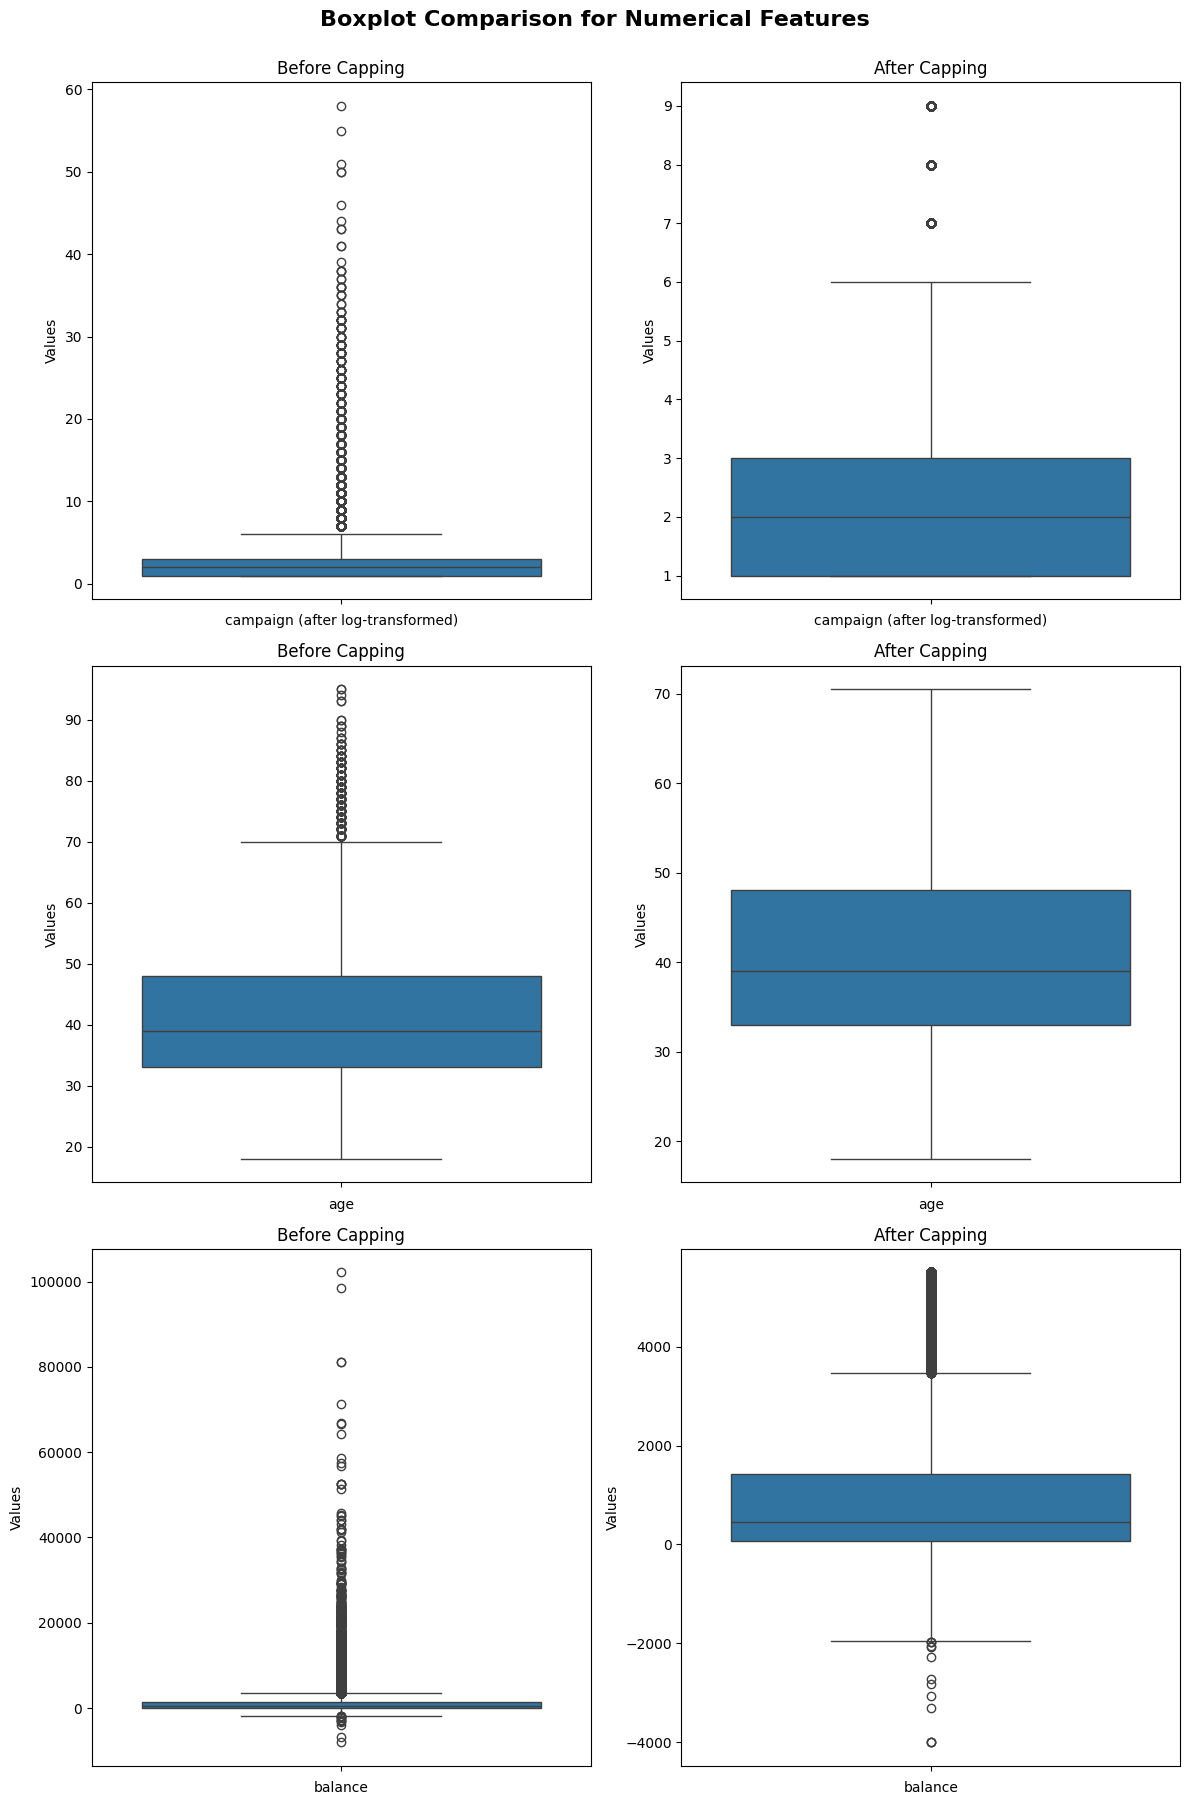

In [44]:
# see the impact of capping:

# define function to apply winsorization - method iqr - tail both - based on fold
# remember that this only on X_train_temp to know the effect, however we will do on X_train later with pipeline

winsorizer_mod_skew = Winsorizer(capping_method='iqr', tail='both', fold=1.5, variables = mod_skew_cols) # for moderate skew
winsorizer_ext_skew = Winsorizer(capping_method='iqr', tail='both', fold=3, variables = ext_skew_cols+ log1p_cols) # for skew

# only apply to train set
X_train_temp_capped = winsorizer_mod_skew.fit_transform(X_train_temp)
X_train_temp_capped = winsorizer_ext_skew.fit_transform(X_train_temp_capped)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 18)) # create 3x2 plot figure

for i in range(len(num_cols)): # i iterate over index on num_cols

    # boxplot before cap
    sns.boxplot(data=X_train_temp[num_cols[i]], ax = axes[i, 0])
    axes[i, 0].set_title('Before Capping')

    if num_cols[i] in log1p_cols:
        axes[i, 0].set_xlabel(f"{num_cols[i]} (after log-transformed)")
    else:
        axes[i, 0].set_xlabel(f"{num_cols[i]}")

    axes[i, 0].set_ylabel('Values')

    # boxplot after cap
    sns.boxplot(data=X_train_temp_capped[num_cols[i]], ax = axes[i, 1])
    axes[i, 1].set_title('After Capping')

    if num_cols[i] in log1p_cols:
        axes[i, 1].set_xlabel(f"{num_cols[i]} (after log-transformed)")
    else:
        axes[i, 1].set_xlabel(f"{num_cols[i]}")
        
    axes[i, 1].set_ylabel('Values')

# display the plot and styling
fig.suptitle('Boxplot Comparison for Numerical Features', fontsize = 16, fontweight = 'bold', y = 1) # overall title on the top
plt.tight_layout()
plt.show()

The outliers seems more handled than before capping method. Hence, we will do this process later with **Pipeline** for preprocessing for numerical features (together with earlier and later preprocessing for numerical features).

If we recap earlier, **list of preprocessing for numerical features** as below (for now):
- For `age`:
    1. `SimpleImputer(strategy = 'median')`
    2. `Winsorizer(capping_method='iqr', tail='both', fold=1.5)`
- For `balance`:
    1. `SimpleImputer(strategy = 'median')`
    2. `Winsorizer(capping_method='iqr', tail='both', fold=3)`
- For `campaign`:
    1. `SimpleImputer(strategy = 'median')`
    2. `FunctionTransformer(np.log1p)`
    3. `Winsorizer(capping_method='iqr', tail='both', fold=3)`
> This is the current state until **Outliers Handling** section, later on **Feature Selection** there may changes for features that will be included for modeling process

And, **list of preprocessing for all categorical features** as below (for now):
1. `SimpleImputer(strategy = 'most_frequent')`

## 7. Feature Selection

On this section, we will check the Phi-K correlation value with `phik` module for all features (numerical and categorical) to check association for each feature with the target `y`:
> **References** to use Phi-K correlation value:
> - [Baak, M., Koopman, R., Snoek, H., & Klous, S. (2019)](https://arxiv.org/pdf/1811.11440)
> - [phik-documentation](https://phik.readthedocs.io/_/downloads/en/stable/pdf/)

In [45]:
# recall that will check Phi-K correlation only on train set

concat_train = pd.concat([X_train[num_cols + cat_cols], 
                          y_train], axis = 1) # concat for below purposes only

# call previously defined compute_phik_correlation function
correlation = compute_phik_correlation(
    concat_train,
    concat_train.columns.to_list(),
    target=['y']
)

# print result
print(correlation.sort_values(by= 'y')) # sort ascending

interval columns not set, guessing: ['campaign', 'age', 'balance']
                  y
day        0.030654
default    0.032626
marital    0.040673
campaign   0.072293
balance    0.078145
contact    0.090785
loan       0.098653
education  0.109065
job        0.134029
month      0.147811
age        0.197588
housing    0.209419
poutcome   0.454122
y          1.000000


From above output, if phi-k value 0 means the feature does not have association with target `y`. For the threshold, we may want to exclude the features with Phi-K correlation value lower than 0.095. Therefore, we will **drop features `day`,`default`, `marital`, `balance`, `campaign`, and `contact`**, since all Phi-K correlation value with the target variable is lower than 0.095 :

In [46]:
# remove on cat_cols:
cat_cols.remove('day')
cat_cols.remove('default')
cat_cols.remove('marital')
cat_cols.remove('contact')

# remove on num_cols
num_cols = ['age'] # only age left

Hence, after feature selection recap from earlier that **list of preprocessing for numerical features** (only `age` column) as below (for now):
1. `SimpleImputer(strategy = 'median')`
2. `Winsorizer(capping_method='iqr', tail='both', fold=1.5)`
> Since the feature `campaign` is dropped, we no longer use `FunctionTransformer(np.log1p)`, so we ended up not needed this library in this project

And, **list of preprocessing for all categorical features** as below (for now):
1. `SimpleImputer(strategy = 'most_frequent')`

## 8. Feature Transformation

In order to prevent data leakage, in this project later we will use **Cross-Validation** when training model. Also, we will define our preprocessing with **Pipeline** alongwith `ColumnTransformer`. So, the scaling and encoding process will only be fitted on the train-set to prevent **overfit to test set**, because later will use cross-validation on pipeline. In this section, we will separate (continuation of) preprocessing of numerical and categorical features. Below section is only to see the behavior and to list the results **if we do the encoding and scaling process**. However, we will **not replace** with original `X_train` and `X_test` for now (to prevent overfit to test set, since we will do cross validation).

### 8A. Feature Encoding

All categorical feature have been checked before on **Cardinality Handling**, all features are not yet encoded:

In [47]:
start = True # only print line not on the first print

# recheck categorical
# loop on categorical column :
for col in cat_cols:
    
    if not start:
        print() # separate line

    print(X_train[col].value_counts())

    start = False

job
blue-collar    7764
management     7536
other          7315
technician     6096
admin.         4121
services       3324
Name: count, dtype: int64

education
secondary    18620
tertiary     10591
primary       5472
unknown       1473
Name: count, dtype: int64

housing
yes    20102
no     16054
Name: count, dtype: int64

loan
no     30347
yes     5809
Name: count, dtype: int64

month
apr - jun    17573
jul - sep    11000
oct - dec     3940
jan - mar     3643
Name: count, dtype: int64

poutcome
unknown    29553
failure     3957
other       1449
success     1197
Name: count, dtype: int64


By above output, we can split these categorical columns:
- Ordinal : [`month`]
- Nominal : [`job`, `education`, `housing`, `loan`, `poutcome`]
> `education` included to nominal because there is value **unknown** that cannot be ordered with other values

We will use `OneHotEncoder` for nominal features, and `OrdinalEncoder` for ordinal features. 
> Remember that we will **not replace** with original `X_train` and `X_test`, as below process only to know the results **if we do the encoding process**

In [48]:
# split nominal and ordinal
ordinal = ['month']
nominal = ['job', 'education', 'housing', 'loan', 'poutcome']

# define the encoder only to know the results if we do the encoding process
ordinal_encoder = OrdinalEncoder()

# define encoded as new value
X_train_cat_oe_encoded = X_train[ordinal].copy() # use copy() in order not replace with original X_train
X_test_cat_oe_encoded = X_test[ordinal].copy() # use copy() in order not replace with original X_test

# fit and transform
X_train_cat_oe_encoded = ordinal_encoder.fit_transform(X_train_cat_oe_encoded) # fit and transform for train
X_test_cat_oe_encoded = ordinal_encoder.transform(X_test_cat_oe_encoded) # transform for test

# review after oe encoded
X_train_cat_oe_encoded = pd.DataFrame(X_train_cat_oe_encoded, columns = ordinal_encoder.get_feature_names_out().tolist())
print(X_train_cat_oe_encoded.value_counts().sort_index())
X_train_cat_oe_encoded

month
0.0      17573
1.0       3643
2.0      11000
3.0       3940
Name: count, dtype: int64


,month
0,0.0
1,0.0
2,2.0
3,0.0
4,0.0
...,...
36151,2.0
36152,2.0
36153,2.0
36154,3.0


In [49]:
# define the encoder only to know the results if we do the encoding process

nominal_encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop = 'first', # to drop first category in each feature to prevent dummy variable trap
    sparse_output=False
)

# define encoded as new value
X_train_cat_ohe_encoded = X_train[nominal].copy() # use copy() in order not replace with original X_train
X_test_cat_ohe_encoded = X_test[nominal].copy() # use copy() in order not replace with original X_test

# fit and transform
X_train_cat_ohe_encoded = nominal_encoder.fit_transform(X_train_cat_ohe_encoded) # fit and transform for train
X_test_cat_ohe_encoded = nominal_encoder.transform(X_test_cat_ohe_encoded) # transform for test

# review after ohe encoded
X_train_cat_ohe_encoded = pd.DataFrame(X_train_cat_ohe_encoded, columns = nominal_encoder.get_feature_names_out().tolist())
X_train_cat_ohe_encoded

,job_blue-collar,job_management,job_other,job_services,job_technician,education_secondary,education_tertiary,education_unknown,housing_yes,loan_yes,poutcome_other,poutcome_success,poutcome_unknown
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
36151,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
36152,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
36153,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
36154,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


> **Additional Note:**<br>
> Above code use drop parameter to be `'first'` to avoid dummy variable that highly correlated. References: <br>
> - [dummy-variable-trap](https://www.learndatasci.com/glossary/dummy-variable-trap/)
> - [which-ml-algorithms-affected-by-dummy-variable-trap](https://stats.stackexchange.com/questions/415841/which-ml-algorithms-are-affected-by-dummy-variable-trap)
> - [is-svm-sensitive-to-correlation-between-attributes](https://stats.stackexchange.com/questions/149662/is-support-vector-machine-sensitive-to-the-correlation-between-the-attributes/149907#149907)

Above outputs show the process after encoding process of each categorical features. Later we will apply this with **Pipeline** along with `ColumnTransformer` for **preprocessing**, together when **training** model with **Cross-Validation** technique.

Hence, we conclude **list of preprocessing for all categorical columns** can be splitted as below:
- Ordinal : [`month`] (this list assigned to the variable `ordinal`)
    1. `SimpleImputer(strategy = 'most_frequent')`
    2. `OrdinalEncoder()`
- Nominal : [`job`, `education`, `housing`, `loan`, `poutcome`] (this list assigned to the variable `nominal`)
    1. `SimpleImputer(strategy = 'most_frequent')`
    2. `OneHotEncoder(handle_unknown="ignore", drop='first', sparse_output=False)`

#### Label Encoding

Earlier on the **Split features and target** section we found that the target variable is not encoded yet, we will encode the value in this section :

In [50]:
# feature Encoding - target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
y_train_encoded

array([0, 0, 0, ..., 0, 1, 0])

In [51]:
# save the Class Names into a variable `classes`

classes = le.classes_
classes

array(['no', 'yes'], dtype=object)

By above result we have done encoded the target variable `y` and mapping the values `no` → `0` and `yes` → `1`.

### 8B. Feature Scaling

All numerical features selected earlier have been done **Outliers Handling** earlier. If we recheck to the list of all numerical columns selected:

In [52]:
# recheck numerical columns selected
num_cols

['age']

By **Feature Selection** and earlier result on **Outliers Handling** we ended up with only `age` for numerical feature for modeling. Since previously proven that `age` not normally distributed and **moderately skew** (store in `mod_skew_cols` list variable), the scaling will use `MinMaxScaler()`, if we see the result:
> Same as encoding, we will **not replace** with original `X_train` and `X_test`, as below process only to know the results **if we do the encoding process**

In [53]:
# define scaler
scaler = MinMaxScaler()

# re defined the capping since some of variables dropped from earlier
winsorizer_mod = Winsorizer(capping_method='iqr', tail='both', fold=1.5) # for moderate skew
X_train_mod = X_train[mod_skew_cols].copy() # in order not replace original X_train
X_train_mod_capped = winsorizer_mod.fit_transform(X_train_mod)
X_train_mod_capped_scaled = scaler.fit_transform(X_train_mod_capped)

# since X_test not capped earlier
# later with pipeline and cross-validation
# validation set and test set will be .transform of the winsorizer as well
X_test_mod = X_test[mod_skew_cols].copy() # in order not replace original X_test
X_test_mod_capped = winsorizer_mod.transform(X_test_mod)
X_test_mod_capped_scaled = scaler.transform(X_test_mod_capped)

# review after minmax scaled
X_train_mod_capped_scaled = pd.DataFrame(X_train_mod_capped_scaled, columns = winsorizer_mod.get_feature_names_out())
X_train_mod_capped_scaled

,age
0,0.133333
1,0.533333
2,0.457143
3,0.285714
4,0.495238
...,...
36151,0.628571
36152,0.285714
36153,0.380952
36154,1.000000


Above output show the result scaling process *if* we do from train and test set.

Hence, we conclude **list of preprocessing for all numerical columns** (which only column `age`) as below:
1. `SimpleImputer(strategy = 'median')`
2. `Winsorizer(capping_method='iqr', tail='both', fold=1.5)`
3. `MinMaxScaler()`

## 9. Preprocessing with `ColumnTransformer`

Combine **preprocessing** with separately for each that we specified earlier in **Feature Encoding** and **Feature Scaling** section:

In [54]:
## pipeline for numerical features
num_pipeline = make_pipeline(
    SimpleImputer(strategy = 'median'), # first step
    Winsorizer(capping_method='iqr', tail='both', fold=1.5), # second step
    MinMaxScaler() # third step
)

## pipeline for categorical ordinal features
cat_ord_pipeline = make_pipeline(
    SimpleImputer(strategy = 'most_frequent'), # first step
    OrdinalEncoder() # second step
)

## pipeline for categorical nominal features
cat_nom_pipeline = make_pipeline(
    SimpleImputer(strategy = 'most_frequent'), # first step
    OneHotEncoder(handle_unknown="ignore", 
                  drop='first', sparse_output=False) # second step
)


# define columntransformer for preprocessing
preprocess = ColumnTransformer(
    transformers = [
        ('pipe_cat_ord', cat_ord_pipeline, ordinal), # for all in ordinal
        ('pipe_cat_nom', cat_nom_pipeline, nominal), # for all in nominal
        ('pipe_num', num_pipeline, num_cols) # for all in num_cols
    ]
)

preprocess

ColumnTransformer(transformers=[('pipe_cat_ord',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder())]),
                                 ['month']),
                                ('pipe_cat_nom',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['job', 'education', 'housing', 'loan',
                                  'poutcome']),
                                ('pipe_num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('winsorizer',
                                                  Winsorizer(capping_method='iqr',
                                                             fold=1.5,
                                                             tail='both')),
                                                 ('minmaxscaler',
                                                  MinMaxScaler())]),
                                 ['age'])])

# vi. Model Definition

The algorithms used in this project are **KNN**, **SVM**, **Decision Tree**, **Random Forest**, and **Boosting** (`AdaBoostClassifier` from Scikit-Learn). The target variable `y`, that is we will predict whether the client will subscribe to a term deposit products when called later on future campaigns, based on all features from historical dataset (of previous campaign and more past campaigns). Therefore, this problem is **binary classification task**.

The idea for application of these several model is to choose the best of models based on these algorithms, with this dataset, on this project. It is suitable to use **KNN** and **Decision Tree** because both algorithms are nonparametric, so not restricted with assumptions that may not suitable with the dataset in this project. It also suitable to use **SVM** algorithm because of the ability to handle non-linear data, since the data in real world problems are non linear data, some outliers normally still persists (handled but not gone completely). Lastly, it is suitable to conduct modeling with **Random Forest** and **Boosting** algorithms since both are algorithms from machine learning technique **ensemble learning** that involves multiple individual models to create a stronger model.

To evaluate the best of all models will be focus to use **Confusion Matrix** and **Precision score**. The primary focus is to minimizing the **False Positive**. Because the target variable `y` is binary variable where 1 : yes (positive) and 0 : no (negative). We focus to make the lowest **False Positive**, since the most problem case is when the machine learning model predicted positive (yes, the person **will** subscribe a term deposit), but actual value is negative (no, the person **actually** not subscribe a term deposit). This may lead the campaign performance of marketing team conducted worsen than before predictive model developed, because of the inefficiency marketing resources.

On the other hand, the other one that is **False Negative**, is **not a concern** here because there is no problem when predicted negative (no, the person will not subscribe a term deposit), but actual value is positive (yes, the person will subscribe a term deposit). Even though this still considered missed prediction, however on this case may still benefit to the company, without using marketing resources, but ended up gained new customer subscriptions.

## Define the Models

Recall that we will use **Pipeline**, hence each model will be inside pipeline together with **preprocessing pipeline** earlier defined on variable `preprocess`. Each model will first defined with default hyperparameter and will be selected the best one before further process **hyperparameter tuning** section.

### Model 1 - KNN :

In [55]:
# KNN model
pipe_knn = make_pipeline(
    preprocess, # preprocess pipeline
    KNeighborsClassifier() # KNN with default parameter n_neighbors
)

pipe_knn

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipe_cat_ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder())]),
                                                  ['month']),
                                                 ('pipe_cat_nom',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'education',
                                                   'housing', 'loan',
                                                   'poutcome']),
                                                 ('pipe_num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsorizer',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['age'])])),
                ('kneighborsclassifier', KNeighborsClassifier())])

### Model 2 - SVM :

We will set kernel `'rbf'` for SVM model since earlier we suggest that our dataset **non-linearly separable** and varying densities with **outliers** stil persists (even after capping process) : 

In [56]:
# SVM model
pipe_svm = make_pipeline(
    preprocess, # preprocess pipeline
    # by default kernel is rbf
    SVC()
)

pipe_svm

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipe_cat_ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder())]),
                                                  ['month']),
                                                 ('pipe_cat_nom',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'education',
                                                   'housing', 'loan',
                                                   'poutcome']),
                                                 ('pipe_num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsorizer',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['age'])])),
                ('svc', SVC())])

### Model 3 - Decision Tree :

In [57]:
# Decision Tree model
pipe_dt = make_pipeline(
    preprocess, # preprocess pipeline
    DecisionTreeClassifier(random_state = random_state) # use default for all hyperparameters of decision tree
)

pipe_dt

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipe_cat_ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder())]),
                                                  ['month']),
                                                 ('pipe_cat_nom',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'education',
                                                   'housing', 'loan',
                                                   'poutcome']),
                                                 ('pipe_num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsorizer',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['age'])])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=35))])

### Model 4 - Random Forest :

Random Forest is algorithm that use **Bagging** technique, one of ensemble learning with Decision Tree as base model:

In [58]:
# Random Forest model
pipe_rf = make_pipeline(
    preprocess, # preprocess pipeline
    RandomForestClassifier(random_state = random_state) # use default for all hyperparameters of randomforest
)

pipe_rf

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipe_cat_ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder())]),
                                                  ['month']),
                                                 ('pipe_cat_nom',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'education',
                                                   'housing', 'loan',
                                                   'poutcome']),
                                                 ('pipe_num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsorizer',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['age'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=35))])

### Model 5 - Boosting :

One of ensemble learning technique is **Boosting**. In Scikit-Learn, the base estimator for `AdaBoostClassifier` is Decision Tree as a base model:

In [59]:
# AdaBoost model
pipe_ada = make_pipeline(
    preprocess, # preprocess pipeline
    # use default estimator that is decision tree
    AdaBoostClassifier(random_state = random_state) # use default for other hyperparameters
)

pipe_ada

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipe_cat_ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder())]),
                                                  ['month']),
                                                 ('pipe_cat_nom',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'education',
                                                   'housing', 'loan',
                                                   'poutcome']),
                                                 ('pipe_num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsorizer',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['age'])])),
                ('adaboostclassifier', AdaBoostClassifier(random_state=35))])

# vii. Model Training

We will do `fit` with **Cross-Validation** to prevent overfit with test-set. Recall that our main objective is to **minimize False Positive**, so our main focus is the scoring to **maximize Precision score**:

In [60]:
# fit the model and evaluate by scoring precision:

## knn
cv_knn = cross_val_score(
    pipe_knn,
    X_train, # cross-validation on train set
    y_train_encoded,
    cv = 5, # use 5 fold
    scoring = 'precision', # the scoring to maximize precision
    n_jobs = -1 # -1 to parallel use all processor
)

## svm
cv_svm = cross_val_score(
    pipe_svm,
    X_train, # cross-validation on train set
    y_train_encoded,
    cv = 5, # use 5 fold
    scoring = 'precision', # the scoring to maximize precision
    n_jobs = -1 # -1 to parallel use all processor
)

## dt
cv_dt = cross_val_score(
    pipe_dt,
    X_train, # cross-validation on train set
    y_train_encoded,
    cv = 5, # use 5 fold
    scoring = 'precision', # the scoring to maximize precision
    n_jobs = -1 # -1 to parallel use all processor
)

## rf
cv_rf = cross_val_score(
    pipe_rf,
    X_train, # cross-validation on train set
    y_train_encoded,
    cv = 5, # use 5 fold
    scoring = 'precision', # the scoring to maximize precision
    n_jobs = -1 # -1 to parallel use all processor
)

## adaboost
cv_ada = cross_val_score(
    pipe_ada,
    X_train, # cross-validation on train set
    y_train_encoded,
    cv = 5, # use 5 fold
    scoring = 'precision', # the scoring to maximize precision
    n_jobs = -1 # -1 to parallel use all processor
)

# viii. Model Evaluation

## Model Evaluation with Precision score

In [61]:
# knn
print('For KNN : ')
print('Precision Score - All - Cross Validation  : ', cv_knn)
print('Precision Score - Mean - Cross Validation : ', cv_knn.mean())
print('Precision Score - Std - Cross Validation  : ', cv_knn.std())
print('Precision Score - Range of Test-Set       : ', (cv_knn.mean()-cv_knn.std()) , '-', (cv_knn.mean()+cv_knn.std()))

print() # separate line

# svm
print('For SVM : ')
print('Precision Score - All - Cross Validation  : ', cv_svm)
print('Precision Score - Mean - Cross Validation : ', cv_svm.mean())
print('Precision Score - Std - Cross Validation  : ', cv_svm.std())
print('Precision Score - Range of Test-Set       : ', (cv_svm.mean()-cv_svm.std()) , '-', (cv_svm.mean()+cv_svm.std()))

print() # separate line

# decision tree
print('For Decision Tree : ')
print('Precision Score - All - Cross Validation  : ', cv_dt)
print('Precision Score - Mean - Cross Validation : ', cv_dt.mean())
print('Precision Score - Std - Cross Validation  : ', cv_dt.std())
print('Precision Score - Range of Test-Set       : ', (cv_dt.mean()-cv_dt.std()) , '-', (cv_dt.mean()+cv_dt.std()))

print() # separate line

# random forest
print('For Random Forest : ')
print('Precision Score - All - Cross Validation  : ', cv_rf)
print('Precision Score - Mean - Cross Validation : ', cv_rf.mean())
print('Precision Score - Std - Cross Validation  : ', cv_rf.std())
print('Precision Score - Range of Test-Set       : ', (cv_rf.mean()-cv_rf.std()) , '-', (cv_rf.mean()+cv_rf.std()))

print() # separate line

# adaboost
print('For AdaBoost : ')
print('Precision Score - All - Cross Validation  : ', cv_ada)
print('Precision Score - Mean - Cross Validation : ', cv_ada.mean())
print('Precision Score - Std - Cross Validation  : ', cv_ada.std())
print('Precision Score - Range of Test-Set       : ', (cv_ada.mean()-cv_ada.std()) , '-', (cv_ada.mean()+cv_ada.std()))

For KNN : 
Precision Score - All - Cross Validation  :  [0.50684932 0.45896657 0.48220065 0.47335423 0.44936709]
Precision Score - Mean - Cross Validation :  0.474147569649949
Precision Score - Std - Cross Validation  :  0.019896837583720118
Precision Score - Range of Test-Set       :  0.45425073206622885 - 0.4940444072336691

For SVM : 
Precision Score - All - Cross Validation  :  [0.69417476 0.65065502 0.69268293 0.68292683 0.64285714]
Precision Score - Mean - Cross Validation :  0.6726593356140637
Precision Score - Std - Cross Validation  :  0.021640885003495633
Precision Score - Range of Test-Set       :  0.6510184506105681 - 0.6943002206175592

For Decision Tree : 
Precision Score - All - Cross Validation  :  [0.36448598 0.37681159 0.35696822 0.34338747 0.38205128]
Precision Score - Mean - Cross Validation :  0.3647409087438392
Precision Score - Std - Cross Validation  :  0.013869387359476223
Precision Score - Range of Test-Set       :  0.35087152138436295 - 0.3786102961033154

Fo

Based on cross-validation result across 5 models, we observe that only **SVM** and **AdaBoost** have relatively good performance by precision score compared to other model candidates. The performance of **KNN**, **Decision Tree**, and **Random Forest** are considerably lower in terms of mean precision score. This results indicates that these 3 models are less competitive for current objective, which is to minimize false positives by maximizing precision, also may because of these 3 models are have tendencies of overfitting, since these 3 models base algorithms have no assumptions.

Between **SVM** and **AdaBoost**, the estimated precision score for unseen test set (based on cross-validation mean) for **SVM** is **67.27 %**, while for **AdaBoost** it is **66.74 %**. Both models show good performance, with **precision score ranges approaching 70 %** (range of test-set from cross-validation point as the center). However, the difference in both mean, standard deviation, and range is slightly between both models, indicates the performance alone is not sufficient to make final decision at this stage.

In addition to predictive performance, model stability and computational efficiency are also important considerations. **AdaBoost** as one of ensemble learning method, requires multiple sequential model fittings for training, makes expensive computation. On the other hand, **SVM** demonstrates comparable performance (with AdaBoost) also with more stable behavior across folds cross-validation performance with lower computational. Since the little marginal performance difference and the needs of efficient model too, **SVM** is selected as **main model** for further evaluation and threshold optimization.

## Hyperparameter Tuning

To improve the ability of the selected SVM model, we will perform **hyperparameter tuning** using **RandomizedSearchCV**. The tuning will be done **inside a Pipeline** and evaluated **using cross-validation**, so all the preprocessing steps are fitted **only to the training folds**. Same as previous, this process is to prevent data leakage and overfit to the test set, so the hyperparameter search only focus to **model robustness** rather than test-set performance.

In [62]:
# define scorer to handle zero division
precision_scorer = make_scorer(precision_score, zero_division = 0) # in order to handle warning if zero_division occurred


# create pipeline for hyperparameter tuning
# do on previously defined pipe_svm

param_rand = {
    'svc__C' : [1e-2, 1e-1, 1, 10, 1e2], # we check for C = 10^-2, 10^-1, ..., 10^2
    'svc__gamma' : [1e-2, 1e-1, 1, 10, 1e2] # we check for gamma = 10^-2, 10^-1, ..., 10^2
}

rand_svm = RandomizedSearchCV(pipe_svm, param_distributions = param_rand,
                          n_iter = 15, cv = 5, # use 5 fold cross-validations in hyperparameter tuning
                          random_state = random_state, n_jobs = -1, # -1 to parallel use all processor
                          scoring = precision_scorer) # the scoring to maximize precision and handle if zero_division occurred

rand_svm.fit(X_train, y_train_encoded) # training model

print('Best cross-validation precision : {:.2f}'.format(rand_svm.best_score_))
print('Best parameters : ', rand_svm.best_params_)

rand_svm.best_estimator_

Best cross-validation precision : 0.69
Best parameters :  {'svc__gamma': 1, 'svc__C': 0.1}


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipe_cat_ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder())]),
                                                  ['month']),
                                                 ('pipe_cat_nom',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'education',
                                                   'housing', 'loan',
                                                   'poutcome']),
                                                 ('pipe_num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsorizer',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['age'])])),
                ('svc', SVC(C=0.1, gamma=1))])

Above output shows the best hyperparameter for SVM model is `gamma = 1` and `C = 0.1` for the selected SVM model earlier as a baseline. Even though the cross-validation precision score after hyperparameter tuning increase but not so many increment from the baseline SVM model (above best cross-validation precision score 69 % still close to 70 %), this result not indicate that tuning process is ineffective. The selected configuration of **regularization strength (`C`)** and **kernel sensitivity (`gamma`)** is more regularized, means expected to reduce variance and improve generalization stability. Therefore, **the tuned SVM model is retained and will be used as final model** for further evaluation.

## Model Evaluation Confusion Matrix

Since previously chosen the hyperparameter tuned SVM model, in this section we will see the performance of this selected model both on train and test set with **Confusion Matrix**. This is to see the real performance of the test set (previously best precision score still based on cross validation) of the best estimator from hyperparameter tuning (SVM with `gamma = 1` and `C = 0.1`), the selected best model:

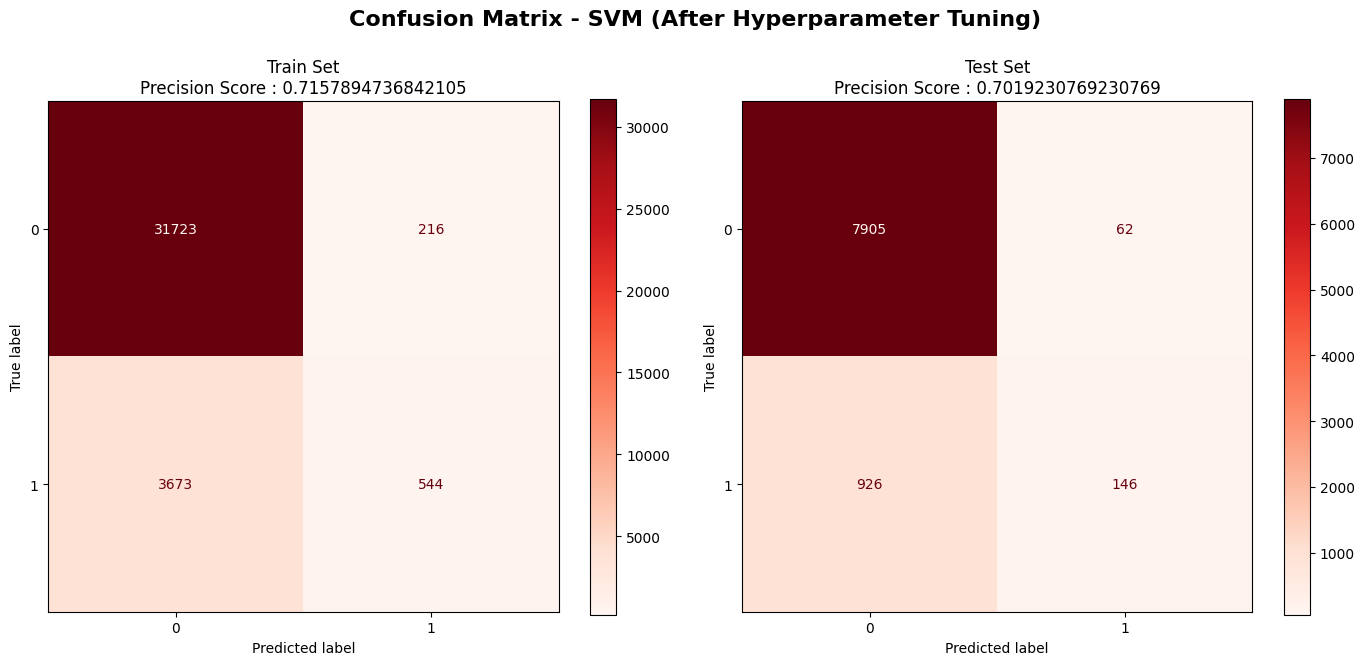

In [63]:
# model best svm :

# use best estimator from hyperparameter tuning
best_svm = rand_svm.best_estimator_

# fit with overall train set
best_svm.fit(X_train, y_train_encoded)

y_pred_train_svm = best_svm.predict(X_train) # predict on train set
y_pred_test_svm = best_svm.predict(X_test) # predict on test set

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (14,6)) # create figure 1x2

# confusion matrix - train set
ConfusionMatrixDisplay.from_estimator(best_svm, X_train, y_train_encoded, cmap = 'Reds', ax = axes[0]) # left side
axes[0].set_title('Train Set\n' + f'Precision Score : {precision_score(y_train_encoded, y_pred_train_svm)}')

# confusion matrix - test set
ConfusionMatrixDisplay.from_estimator(best_svm, X_test, y_test_encoded, cmap = 'Reds', ax = axes[1]) # right side
axes[1].set_title('Test Set\n' + f'Precision Score : {precision_score(y_test_encoded, y_pred_test_svm)}')

# display the plot and styling
fig.suptitle('Confusion Matrix - SVM (After Hyperparameter Tuning)', fontsize = 16, weight = 'bold', y = 1.05) # y for space
plt.tight_layout()
plt.show()

Above result shows performance of the selected model (SVM with `gamma = 1` and `C = 0.1`) we can see the precision score for the train-set is 71.58 %, while for the test-set is 70.19 %. We conclude that this results is **Good-fit** with low variance (the difference of score is 1.49 % < 5 %), and the model not shows significant overfitting behavior. The confusion matrix shows that the selected SVM model produces a relative low number of **False Positive** compared to **True Positive** cases. This behavior aligns with our main objective in this project, which is to **minimizes False Positive predictions**, where the model predicts that customer will subscribe, but actual in reality does not subscribed. Therefore, the model predict conservatively when predicting positive class (`y = 1`), reduce incorrectly targeting customers who are unlikely to subscribe.

## Advantages of the Model

Since our main focus in this project is to **minimize False Positive** or the case when the model predicted positive (yes, the person **will** subscribe a term deposit), but actual value is negative (no, the person **actually** not subscribe a term deposit), our main focus is to the positive prediction in the model. That is, we focus to see the column predicted label is `1` in the Confusion Matrix earlier.

To understand the **advantages** of the selected model, we analyze the characteristics of **True Positive** cases **on the test set** to capture behavior similar with the evaluation on the inference data later. True Positive represents the customers who are correctly predicted positive by model (predicted subscribe to a term deposit). The analysis focuses on the top features with highest association to the target variable, namely `poutcome`, `housing`, and `age`.

In [64]:
# concat the test set for model evaluation

concat_test = pd.concat([
    X_test.reset_index(drop=True), 
    pd.DataFrame(y_test_encoded, columns = ['y_actual']), 
    pd.DataFrame(y_pred_test_svm, columns = ['y_pred'])
], axis = 1 ) # column-wise

# define selected features
selected_features = ['poutcome', 'housing', 'age']

The advantages of the model, is where **True Positive** relies or we can say when the model **successfully predicted positive on actual value positive**, the results are on below:

In [65]:
# true positive
# predicted positive and actual value positive
TP = concat_test[
    (concat_test['y_actual'] == 1) & # actual positive
    (concat_test['y_pred'] == 1) # model predicted positive
][selected_features]

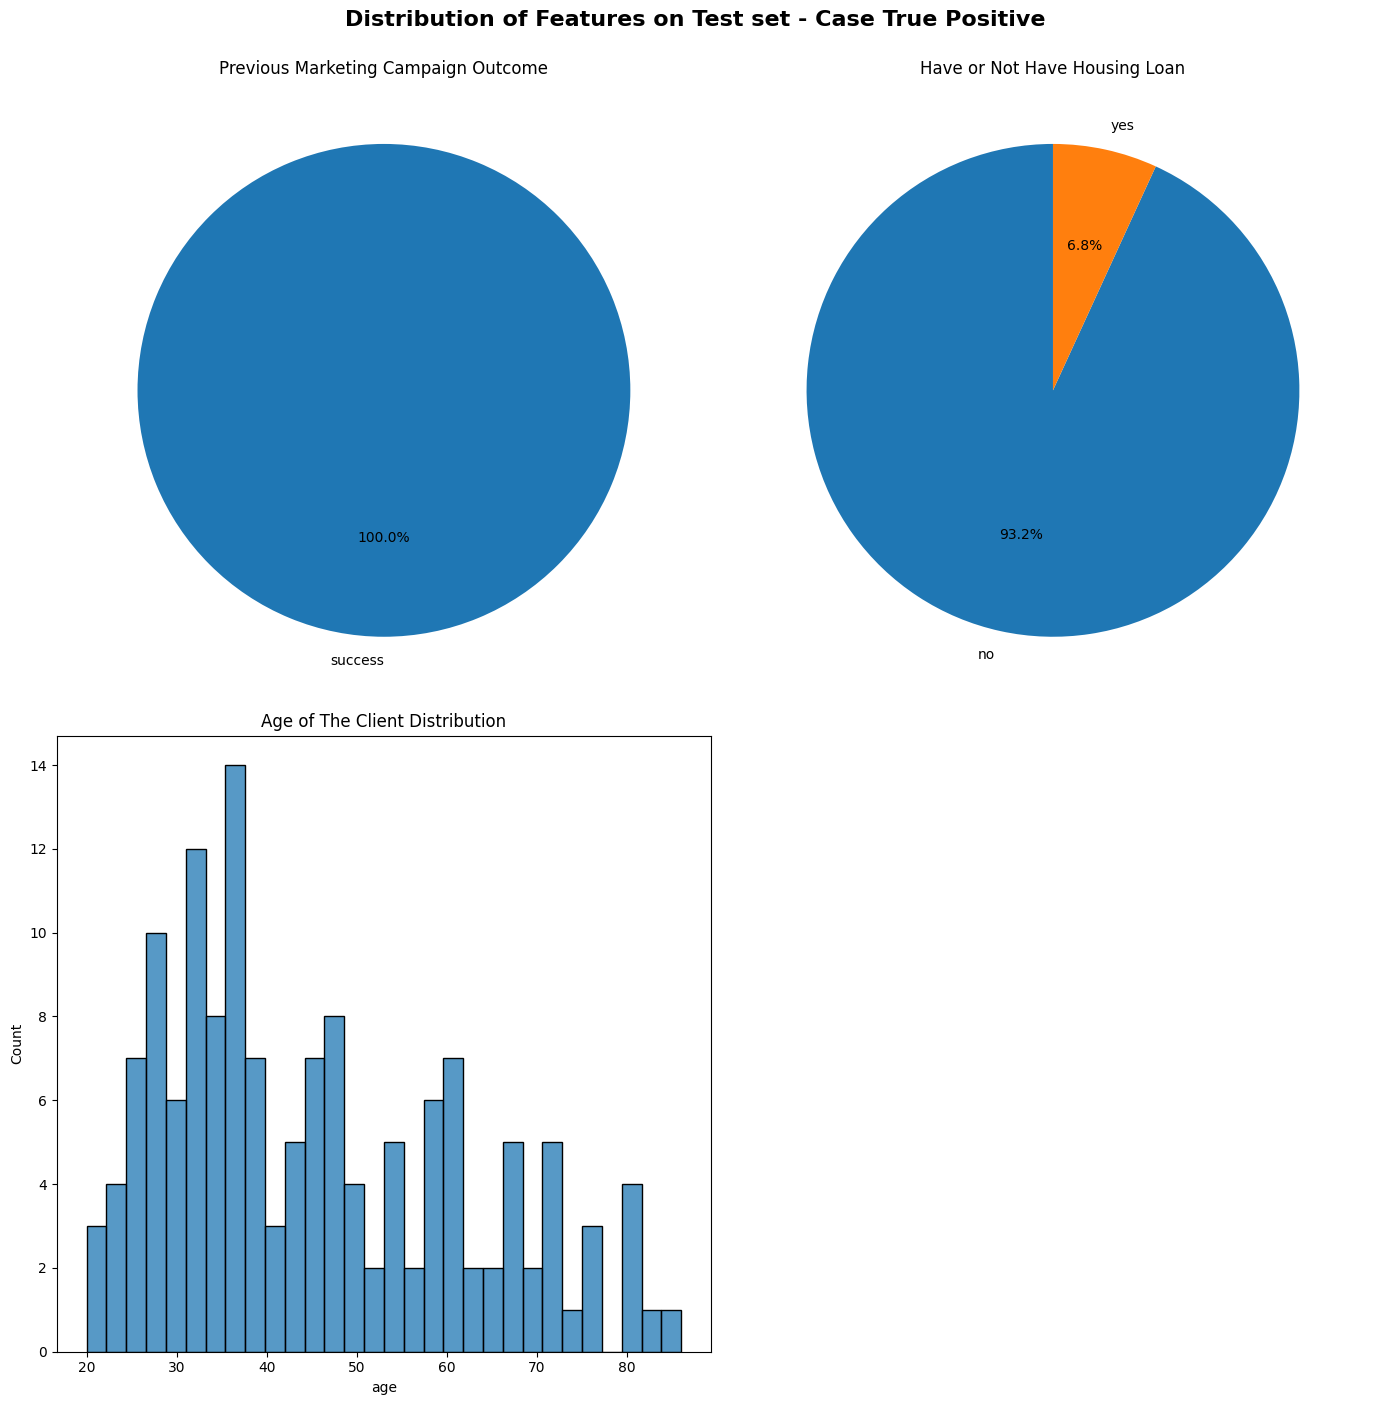

In [66]:
# create 2x2 subplots
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (14, 14))


# first subplot
# pie chart of poutcome
axes[0, 0].pie(
    TP['poutcome'].value_counts(), # the frequency data
    labels = TP['poutcome'].value_counts().index.tolist(), # label for each slice of pie
    autopct = '%1.1f%%', # percentage format 1 number behind decimal
    startangle = 90 # start from 90 degrees
)
axes[0, 0].set_title('Previous Marketing Campaign Outcome')


# second subplot
# pie chart of housing
axes[0, 1].pie(
    TP['housing'].value_counts(), # the frequency data
    labels = TP['housing'].value_counts().index.tolist(), # label for each slice of pie
    autopct = '%1.1f%%', # percentage format 1 number behind decimal
    startangle = 90 # start from 90 degrees
)
axes[0, 1].set_title('Have or Not Have Housing Loan')


# third subplot
# histogram of age
sns.histplot(
    TP['age'], bins = 30, ax = axes[1, 0]
)
axes[1, 0].set_title('Age of The Client Distribution')


# turned off unused axis
axes[1, 1].axis('off')

# display the plot and styling
fig.suptitle('Distribution of Features on Test set - Case True Positive', 
             fontsize = 16, fontweight = 'bold', y = 1)
plt.tight_layout()
plt.show()

From the distribution above, we observe **all True Positive cases are associated with a successful previous marketing campaign (`poutcome = success`)**, means strong signal from historical campaign outcomes. In addition, most correctly predicted subscribers **do not have a housing loan**, suggests these customers that more flexible financial condition. The age distribution also more centered on the **productive working-age**, indicates the model's ability to identify customer profiles that more likely to subscribe. These patterns demonstrate the effective captures from the model of customers from the test set that, these customer patterns are the one that linked to successful predicted customer that likely do a term deposit subscriptions.

## Weakness of the Model

Despite its strong performance, the selected model also shows several **limitations**, which can be seen by analyzing **False Positive** cases on the test set. False Positive represents customer who are predicted to subscribe, but actual in reality is not, which is the main **risk** in this project that we aims to minimize.

The weakness of the model, is where **False Positive** relies or we can say when the model **wrong predicted positive on actual value negative**, the results on below:

In [67]:
# false positive
# predicted positive but actual value negative
FP = concat_test[
    (concat_test['y_actual'] == 0) & # actual negative
    (concat_test['y_pred'] == 1) # model predicted positive
][selected_features]

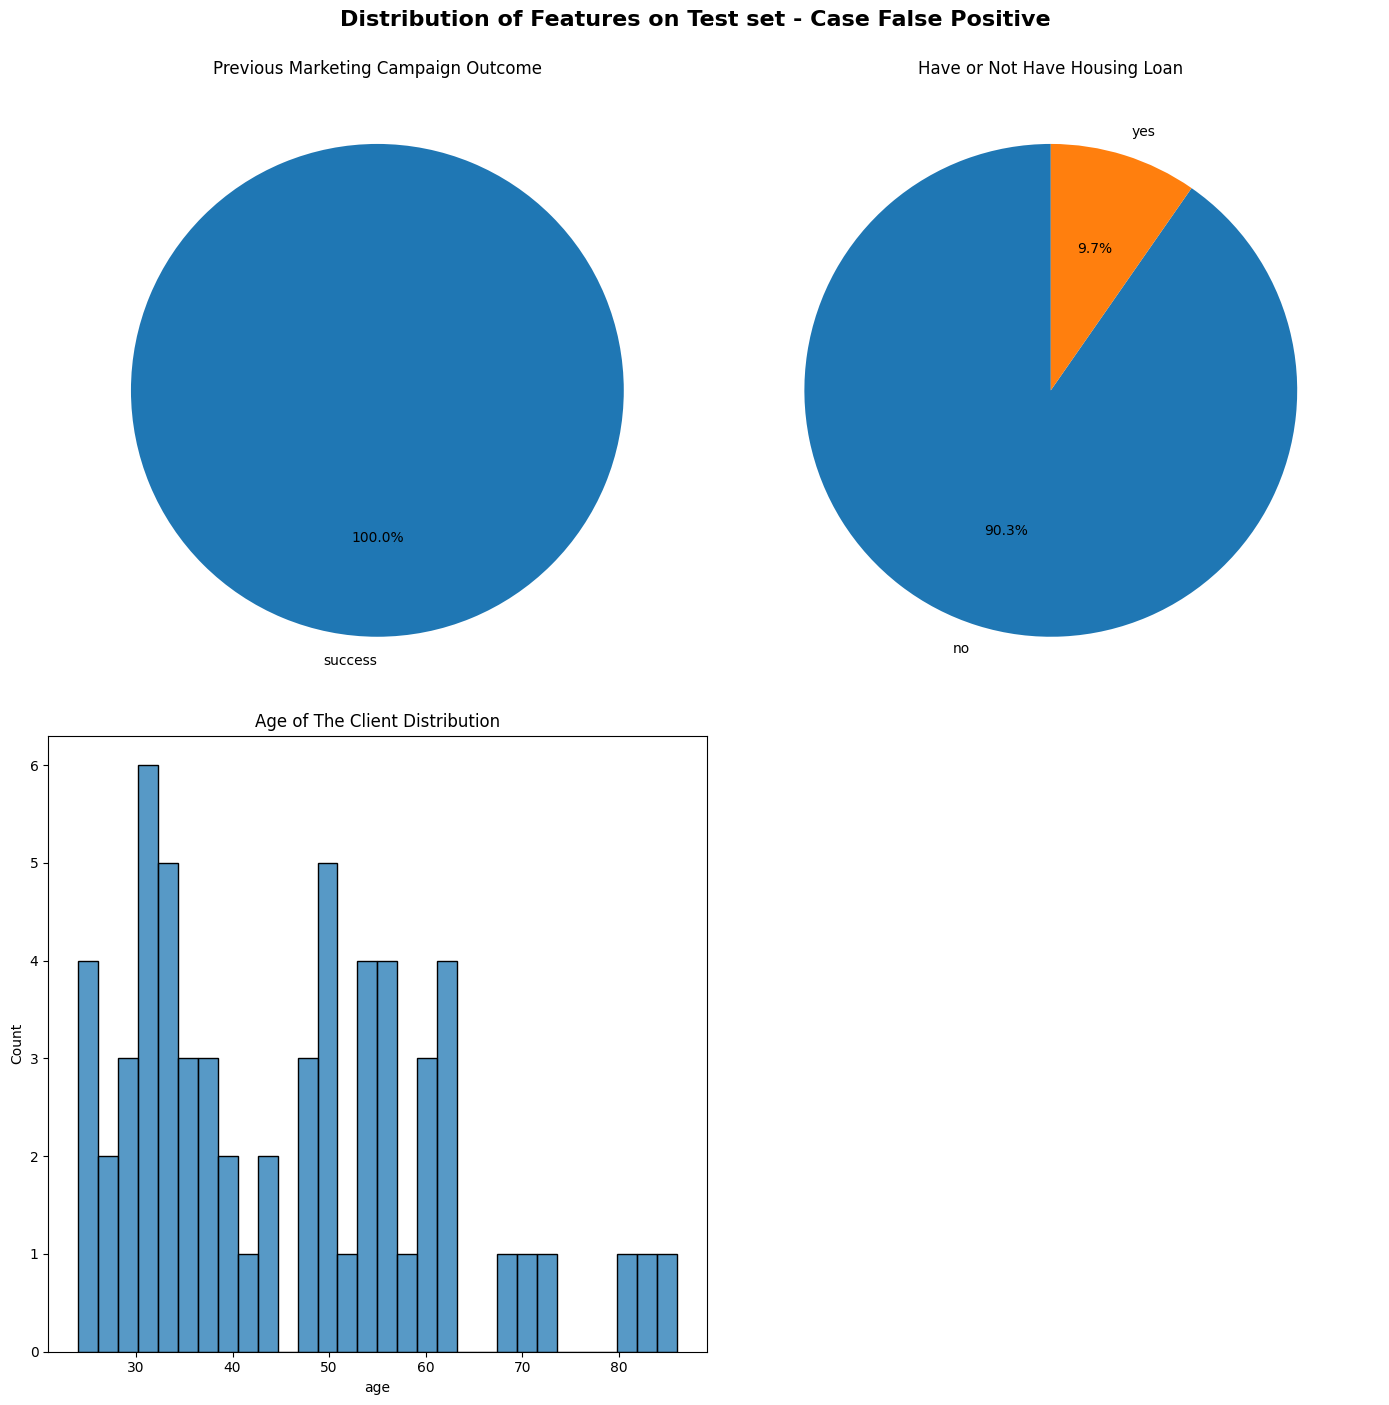

In [68]:
# create 2x2 subplots
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (14, 14))


# first subplot
# pie chart of poutcome
axes[0, 0].pie(
    FP['poutcome'].value_counts(), # the frequency data
    labels = FP['poutcome'].value_counts().index.tolist(), # label for each slice of pie
    autopct = '%1.1f%%', # percentage format 1 number behind decimal
    startangle = 90 # start from 90 degrees
)
axes[0, 0].set_title('Previous Marketing Campaign Outcome')


# second subplot
# pie chart of housing
axes[0, 1].pie(
    FP['housing'].value_counts(), # the frequency data
    labels = FP['housing'].value_counts().index.tolist(), # label for each slice of pie
    autopct = '%1.1f%%', # percentage format 1 number behind decimal
    startangle = 90 # start from 90 degrees
)
axes[0, 1].set_title('Have or Not Have Housing Loan')


# third subplot
# histogram of age
sns.histplot(
    FP['age'], bins = 30, ax = axes[1, 0]
)
axes[1, 0].set_title('Age of The Client Distribution')


# turned off unused axis
axes[1, 1].axis('off')

# display the plot and styling
fig.suptitle('Distribution of Features on Test set - Case False Positive', 
             fontsize = 16, fontweight = 'bold', y = 1)
plt.tight_layout()
plt.show()

From the False Positive distributions, we observe that although `poutcome` remains a strong indicator, the model sometimes still predicts subscription for customers who are not willing to continue (previously success to subscribed but current campaign in actual is not). Some False Positive also appear within similar age ranges and loan status (although a bit lower percentage person that not have housing loan) as True Positive cases earlier. This indicate the overlapping customer characteristics between customer who subscribed and not. This suggests that while the model is conservative, it still struggle to **fully separate** some cases where customer profiles are similar. This limitation reflects the trade-off between maintaining high precision score and stability low variance of the model. Also the difficulties of fully able to separate customer profiles, real-world marketing scenarios where slight differences are difficult to distinguish.

## Model Evaluation - Conclusion

Overall evaluation of the model earlier, the selected SVM model with tuned hyperparameter (`gamma = 1` and `C = 0.1`) shows **stable and consistent performance** across training and test sets. The precision score on the train set is **71.58%**, while on the test set is **70.19%**, which results low variance of **1.49%**, which indicates **Good-Fit**. Based on the cross-validation results, hyperparameter tuning, and confusion matrix analysis, this SVM model is selected as the **final model** for deployment and further inference on unseen dataset.

# ix. Model Saving

Based on the evaluation earlier, the chosen model as the best model in this project is the selected SVM model with tuned hyperparameter (`gamma = 1` and `C = 0.1`). This model previously assigned to the variable `best_svm`, will be saved to the file `term_depo_predictor.pkl` for further data inference:

In [69]:
# save the model file

# the inside the pipeline
with open('term_depo_predictor.pkl', 'wb') as file:
    pickle.dump(best_svm, file)

# x. Model Inference

This section is done on `notebook_inference.ipynb`

# xi. Conclusion

Earlier process on **EDA** section, the analysis upon answering below questions:

1. What is the percentage of subscribed vs. non-subscribed customers in this historical dataset?
2. How is the distribution of subscribed vs non-subscribed customers for each marital status type?
3. When is the date of the year that have the highest frequencies of clients contacted? Are there specific months of the year when past clients are contacted more frequently?
4. Does past campaign informations, which is `pdays`, `previous`, and `poutcome` features have strong association to predict variable whether the client will subscribe term deposit?
5. How is the distribution of numerical features (`age`, `balance`, `campaign`, `pdays`, and `previous`)? Does all have normal distribution? 
6. From the answer of the question no.4, are there numerical features that need logarithmic transformation?

We have done on the **EDA** section above by using pure historical dataset with explanation. From the exploratory analysis, we found that the target variable `y` is imbalanced, where most customers ended up not subscribing to a term deposit in the historical dataset. This condition means that **model evaluation should not use accuracy**, and focus on precision instead to direct marketing resources to more potential customers. From the distribution analysis, we also observed that subscription (target variable `y`) patterns across marital status are similar, where `married` customers from the largest group of `marital` type also have most values on non-subscribed customers compared to customers who subscribed, which again shows the imbalanced of subscribed versus non-subscribed customers. This indicates that `marital` may have some relationship with the target, but may not be strong enough to stand alone as a predictor.

Further analysis on campaign date plot shows that marketing activities were most frequently conducted in May and June, with relatively lower activity in other months. Although the date visualization earlier is useful for operational behaviour insights, it cannot be treated as a true **time series** due to the actual year data is not provided. Therefore, `day` and `month` features are treated as categorical variables in the modeling process. Phi-K correlation analysis of past campaign information shows that `poutcome` has the strongest association with the target variable, while `previous` shows almost no association, suggesting that not all past campaign features have equal relationship to predict the target variable.

Lastly, numerical feature analysis at **EDA** section informed that all numerical variables are not normally distributed, from historical dataset, with mostly have extreme positive skewness distribution. Logarithmic transformation helps stabilize the distribution of `campaign`, while not help in the case of `pdays` and `previous`. It is found earlier that `pdays` and `previous` still **zero-inflated** even after logarithmic transformation and have been checked further in **Outliers Handling** in **Feature Engineering** section, for further modeling process. 

Overall, the EDA results are useful for feature engineering, feature selection, and strategy that help modeling process further. The EDA results also help to gain knowledge of distribution from historical dataset itself, align with busines objectives to improve marketing efficiency by focusing on customers with higher likelihood to subscribe. These EDA findings help to guide modeling process before feature engineering process, and maintain the primary objective for business outcomes.

---

In this project, we have done comparison model with different algorithms **KNN**, **SVM**, **Decision Tree**, **Random Forest**, and **AdaBoost** with default hyperparameters for **binary classification task**. The objective in this project is to predict whether the client is potential to be reached out on marketings campaign for subscribe term deposit or not, by using past campaign historical dataset. Primary focus in this project is to **minimize False Positive**, that is when the model fail to predict subscriber that in reality unlikely to subscribe.

Since the main focus to minimize false positives, between five models chosen the best model with good performance of **Precision score** by conduct inside **Pipeline** with **Cross-Validation** techniques, to reduce data leakage and overfit to the test set. The selected best model from previous five models is **SVM** as a baseline model. The base model is conducted **Hyperparameter Tuning** with **Random Search Cross-Validation** technique, to minimized variance or bias on the model, choose the more stable model, and more regularized model.

The best hyperparameter tuned model is selected for further evaluation with **Confusion Matrix** analysis to evaluate the results on the train set and the test set. The results for the selected SVM model with tuned hyperparameter `gamma = 1` and `C = 0.1` have precision score on the train set **71.58%**, while on the test set **70.19%**, that results low variance of **1.49%**, which indicates **Good-Fit**.

The selected models have good performance as **advantageous** of the model, successfully able to grasps most people with profiles depict customers that likely to subscribe a term deposit products. Nevertheless, also have limitations the **weakness** of the model, that still struggle to **fully separate** some cases where customer profiles are similar, resulted to wrong target people that predicted will subscribe but in reality not on the test set performance. This indicates the customer behavior in marketing campaigns can overlap and the struggle to find the way model perfectly distinguish between customer profiles. Despite these limitations, the selected SVM model still offers the best in this project analysis between precision, stability, and generalization that considered good for practical use and further refinement.

---

As below suggestions can be implemented for further improvement of the model creation:

1. Consider **hurdle model** or **zero-inflated model** to apply on zero-inflated of **campaign past information features `pdays` and `previous`**, as we stated on outliers handling section above
2. Conduct **decision threshold tuning** for optimization cross-validation predictions (precision-recall trade-off analysis) to further reduce false positive rates without accessing the test set
3. Perform analysis on another **bagging model** such as **XGBoost** and **Gradient Boosting**
4. Conduct analysis on **model with another ensemble learning technique** such as **Stacking** type
5. Perform **Oversampling** process with **SMOTE** or **SMOTENC** or combine with **Undersampling** as well to handle imbalanced data